# Proyecto RAG: Recuperacion Aumentada para Preguntas sobre Manual de Convivencia de un Conjunto Residencial

**Autores:** Fredy Sarmiento, Manuel Caro y Jorge Bravo  
**Asignatura:** Aplicaciones de Aprendizaje Automatico de Maquina  
**Universidad:** Universidad del Rosario

## Descripción

1. Este notebook es un ejercicio academico para aprender RAG paso a paso.
2. RAG significa *Retrieval-Augmented Generation*: primero recuperamos evidencia y luego generamos una respuesta.
3. Como alumnos, buscamos entender cada bloque antes de optimizarlo o automatizarlo.
4. El PDF se transforma en documentos, capitulos, citas y fragmentos recuperables.
5. Los embeddings convierten texto en vectores para buscar similitud semantica.
6. FAISS funciona como indice local para recuperar pasajes relevantes rapidamente.
7. OpenAI se usa para embeddings y varias cadenas de respuesta/evaluacion.
8. Gemini se usa como modelo comparativo en las etapas donde antes se usaba Groq.
9. LangGraph organiza el flujo como nodos, estados y decisiones.
10. RAGAS permite evaluar respuestas con metricas de relevancia, fidelidad y similitud.
11. Las claves API se leen desde variables de entorno para no guardarlas en el notebook.
12. Cada seccion esta documentada para que el flujo sea comprensible para estudiantes que estan aprendiendo RAG.

## Flujo documentado del notebook

1. **Preparacion del entorno:** se importan librerias de LangChain, LangGraph, FAISS, OpenAI, Gemini, RAGAS y utilidades locales.
2. **Configuracion de credenciales:** se leen `OPENAI_API_KEY` y `GOOGLE_API_KEY` desde el entorno. No deben escribirse en el codigo.
3. **Carga del PDF:** se define la ruta del libro y se carga con `PyPDFLoader`.
4. **Preprocesamiento:** se limpian tabulaciones, saltos dobles y caracteres que dificultan la recuperacion.
5. **Division por capitulos:** el libro se separa en documentos mas manejables para resumir y consultar.
6. **Extraccion de citas/pasajes:** se extraen citas literales; si el PDF no conserva comillas, se usan pasajes largos como respaldo.
7. **Resumen de capitulos:** un LLM resume cada capitulo para crear una vista compacta del contenido.
8. **Creacion de embeddings:** OpenAI transforma fragmentos, resumenes y citas en vectores numericos.
9. **Persistencia en FAISS:** los vectores se guardan localmente para no recalcularlos en cada ejecucion.
10. **Recuperacion:** para una pregunta, se buscan fragmentos, resumenes y citas semanticamente cercanos.
11. **Destilacion:** un modelo filtra el contenido recuperado y conserva solo la evidencia util.
12. **Respuesta:** el modelo responde usando el contexto recuperado, no memoria libre.
13. **Verificacion:** se revisa si la respuesta esta soportada por los documentos y si contesta la pregunta.
14. **Grafos simples:** LangGraph conecta recuperacion, filtrado, respuesta y validacion.
15. **Agente avanzado:** el notebook muestra un flujo Plan-and-Execute que planea, recupera, responde y replantea.
16. **Evaluacion:** RAGAS compara preguntas, contextos, respuestas generadas y respuestas esperadas.
17. **Aprendizaje esperado:** comprender que un buen sistema RAG depende tanto de datos limpios y recuperacion correcta como del modelo generador.

## Notas Adicionales

Este notebook no debe leerse como una caja negra. La idea es observar que cada respuesta nace de una cadena: documento original -> limpieza -> chunks -> embeddings -> recuperacion -> contexto -> generacion -> evaluacion. Si una respuesta falla, revisamos la cadena completa, no solo el modelo.

Basado en el repositorio:  https://github.com/FareedKhan-dev/complex-RAG-guide

In [57]:
import dotenv
import os

# Esto busca el archivo .env y carga las variables en os.environ
dotenv.load_dotenv()
# --- Importaciones de LangChain y modelos de lenguaje ---
from langchain_openai import ChatOpenAI 
from langchain_google_genai import ChatGoogleGenerativeAI

# --- Carga de documentos e indice vectorial ---
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings 

# --- Prompts y utilidades de documentos ---
from langchain_core.prompts import PromptTemplate
from langchain_core.documents import Document
from langchain_classic.chains.summarize import load_summarize_chain

# --- Modelos de salida estructurada y parsers ---
from pydantic import BaseModel, Field
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.runnables.graph import MermaidDrawMethod

# --- LangGraph para construir flujos de trabajo como grafos ---
from langgraph.graph import END, StateGraph
from langgraph.errors import GraphRecursionError

# --- Librerias estandar de Python ---
from time import monotonic
from dotenv import load_dotenv
from pprint import pprint
import os

# --- Datasets, tipos y visualizacion dentro del notebook ---
from datasets import Dataset
from typing_extensions import TypedDict
from IPython.display import display, Image
from typing import List, TypedDict

# --- Metricas RAGAS para evaluar la calidad del sistema RAG ---
from ragas import evaluate
from ragas.metrics import (
    answer_correctness,
    faithfulness,
    answer_relevancy,
    context_recall,
    answer_similarity
)

import langgraph

# --- Funciones auxiliares del proyecto ---
from helper_functions import (
    num_tokens_from_string,
    replace_t_with_space,
    replace_double_lines_with_one_line,
    split_into_chapters,
    analyse_metric_results,
    escape_quotes,
    text_wrap,
    extract_book_quotes_as_documents
)

# --- Carga variables de entorno como OPENAI_API_KEY y GOOGLE_API_KEY ---
load_dotenv(override=True)

# --- Aumenta el tiempo de espera de depuracion para evitar advertencias durante llamadas largas ---
os.environ["PYDEVD_WARN_EVALUATION_TIMEOUT"] = "100000"



### Configuracion de claves API de OpenAI y Google Gemini


In [58]:
# --- Configuracion de claves para OpenAI y Google Gemini ---

# Leemos la clave de OpenAI desde el entorno.
# No se escribe la clave en el notebook para evitar exponer credenciales.
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY", "")

# Leemos la clave de Google Gemini desde el entorno.
# Esta variable se entrega al modelo Gemini cuando el notebook compara modelos.
google_api_key = os.getenv('GOOGLE_API_KEY')



# Preprocesamiento de datos


### Definicion de la ruta del PDF


In [59]:
# Definimos la ruta del archivo PDF que sera la fuente principal de conocimiento.
# En RAG, esta fuente documental es la evidencia que el modelo debe consultar antes de responder.
hp_pdf_path = "MANUAL DE CONVIVENCIA CONJUNTO RESIDENCIAL AMARANTO CLUB HOUSE.pdf"



### Division del PDF en capitulos y limpieza inicial


In [60]:
# --- Division del PDF en capitulos y limpieza del texto ---

# 1. Separamos el libro en capitulos usando una funcion auxiliar.
#    Cada capitulo queda como un objeto Document con texto y metadatos.
chapters = split_into_chapters(hp_pdf_path)

# 2. Limpiamos tabulaciones para que los fragmentos sean mas consistentes.
#    Esta limpieza mejora la calidad de los embeddings y de la recuperacion.
chapters = replace_t_with_space(chapters)

# 3. Mostramos cuantos capitulos se detectaron para validar el preprocesamiento.
print(len(chapters))



133


### Creacion de una lista de citas y pasajes del libro


In [61]:
# --- Carga, limpieza y extraccion de citas/pasajes del PDF ---

# 1. Cargamos el PDF como una lista de documentos por pagina.
loader = PyPDFLoader(hp_pdf_path)
document = loader.load()

# 2. Limpiamos caracteres que pueden afectar la busqueda semantica.
document_cleaned = replace_t_with_space(document)

# 3. Extraemos citas o pasajes largos como documentos independientes.
#    Estos pasajes se usaran como una tercera fuente de recuperacion junto con chunks y resumenes.
book_quotes_list = extract_book_quotes_as_documents(document_cleaned)



### Definicion del prompt para resumir capitulos


In [62]:
# --- Plantilla de Prompt para Resumenes generados por LLM ---

# Define la plantilla para resumir.
# Esta plantilla instruye al modelo de lenguaje para que escriba un resumen extenso del texto proporcionado.
# NOTA CORREGIDA: El prompt ahora esta en español y contextualiza el tipo de documento (manual de convivencia)
# para que el LLM genere resumenes precisos y relevantes.
summarization_prompt_template = """Escribe un resumen extenso y detallado del siguiente fragmento de un manual de convivencia de un conjunto residencial. Extrae las normas, reglas, obligaciones, prohibiciones y procedimientos mencionados:

{text}

RESUMEN:"""

# Crea un objeto PromptTemplate usando la plantilla.
# La variable de entrada "text" sera reemplazada por el contenido a resumir.
summarization_prompt = PromptTemplate(
    template=summarization_prompt_template,
    input_variables=["text"]
)

### Funcion para crear resumenes de capitulos con LLMs


In [63]:
def create_chapter_summary(chapter):
    """
    Crea un resumen de un capitulo usando un modelo de lenguaje grande (LLM).

    Args:
        chapter: Un objeto Document que representa el capitulo a resumir.

    Returns:
        Un objeto Document que contiene el resumen del capitulo.
    """

    # Extraer el contenido de texto del capitulo
    chapter_txt = chapter.page_content

    # Especificar el modelo LLM y la configuracion
    model_name = "gpt-3.5-turbo-0125"
    llm = ChatOpenAI(temperature=0, model_name=model_name)
    gpt_35_turbo_max_tokens = 16000  # Limite maximo de tokens para el modelo
    verbose = False  # Establecer a True para una salida mas detallada

    # Calcular el numero de tokens en el texto del capitulo
    num_tokens = num_tokens_from_string(chapter_txt, model_name)

    # Elegir el tipo de cadena de resumen segun el numero de tokens
    if num_tokens < gpt_35_turbo_max_tokens:
        # Para capitulos mas cortos, usar el tipo de cadena "stuff"
        chain = load_summarize_chain(
            llm,
            chain_type="stuff",
            prompt=summarization_prompt,
            verbose=verbose
        )
    else:
        # Para capitulos mas largos, usar el tipo de cadena "map_reduce"
        chain = load_summarize_chain(
            llm,
            chain_type="map_reduce",
            map_prompt=summarization_prompt,
            combine_prompt=summarization_prompt,
            verbose=verbose
        )

    # Iniciar temporizador para medir el tiempo de resumen
    start_time = monotonic()

    # Crear un objeto Document para el capitulo
    doc_chapter = Document(page_content=chapter_txt)

    # Generar el resumen usando la cadena seleccionada
    summary_result = chain.invoke([doc_chapter])

    # Imprimir el tipo de cadena y el tiempo de ejecucion para referencia
    print(f"Tipo de cadena: {chain.__class__.__name__}")
    print(f"Tiempo de ejecucion: {monotonic() - start_time}")

    # Limpiar el texto del resumen (eliminar saltos de linea dobles, etc.)
    summary_text = replace_double_lines_with_one_line(summary_result["output_text"])

    # Crear un objeto Document para el resumen, preservando los metadatos del capitulo
    doc_summary = Document(page_content=summary_text, metadata=chapter.metadata)

    return doc_summary

### Generacion de resumenes para cada capitulo


In [64]:
# --- Generar resumenes para cada capitulo (con cache para no re-ejecutar) ---

# Para evitar gastar tokens y procesamiento en cada prueba, guardamos los resumenes
# en un archivo pickle. Si el archivo ya existe, se cargan desde ahi.
import pickle

CACHE_SUMMARIES_FILE = "chapter_summaries_cache.pkl"

if os.path.exists(CACHE_SUMMARIES_FILE):
    # Cargar resumenes desde cache para no volver a ejecutar el LLM
    print("Cargando resumenes de capitulos desde cache...")
    with open(CACHE_SUMMARIES_FILE, "rb") as f:
        chapter_summaries = pickle.load(f)
    print(f"Se cargaron {len(chapter_summaries)} resumenes desde cache.")
else:
    # Inicializar una lista vacia para almacenar los resumenes de cada capitulo
    chapter_summaries = []
    # Iterar sobre cada capitulo en la lista de capitulos
    for chapter in chapters:
        # Generar un resumen para el capitulo actual usando la funcion create_chapter_summary
        summary = create_chapter_summary(chapter)
        # Agregar el resumen a la lista chapter_summaries
        chapter_summaries.append(summary)
    # Guardar resumenes en cache para futuras ejecuciones
    with open(CACHE_SUMMARIES_FILE, "wb") as f:
        pickle.dump(chapter_summaries, f)
    print(f"Se guardaron {len(chapter_summaries)} resumenes en cache.")

Cargando resumenes de capitulos desde cache...
Se cargaron 133 resumenes desde cache.


# Codificacion vectorial de los datos


### Funcion para codificar el libro en un vector store con embeddings de OpenAI


In [65]:
def encode_book(path, chunk_size=1000, chunk_overlap=200):
    """
    Codifica un libro PDF en un almacen vectorial FAISS usando embeddings de OpenAI.

    Args:
        path (str): La ruta al archivo PDF.
        chunk_size (int): El tamaño deseado de cada fragmento de texto.
        chunk_overlap (int): La cantidad de solapamiento entre fragmentos consecutivos.

    Returns:
        FAISS: Un almacen vectorial FAISS que contiene el contenido codificado del libro.
    """

    # 1. Cargar el documento PDF usando PyPDFLoader
    loader = PyPDFLoader(path)
    documents = loader.load()

    # 2. Dividir el documento en fragmentos para embedding
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len
    )
    texts = text_splitter.split_documents(documents)

    # 3. Limpiar los fragmentos de texto (reemplazar caracteres no deseados)
    cleaned_texts = replace_t_with_space(texts)

    # 4. Crear embeddings de OpenAI y codificar los fragmentos de texto limpios en un almacen vectorial FAISS
    embeddings = OpenAIEmbeddings()
    vectorstore = FAISS.from_documents(cleaned_texts, embeddings)

    # 5. Devolver el almacen vectorial
    return vectorstore

### Codificacion de resumenes de capitulos en un vector store


In [66]:
def encode_chapter_summaries(chapter_summaries):
    """
    Codifica una lista de resumenes de capitulos en un almacen vectorial FAISS usando embeddings de OpenAI.

    Args:
        chapter_summaries (list): Una lista de objetos Document que representan los resumenes de capitulos.

    Returns:
        FAISS: Un almacen vectorial FAISS que contiene los resumenes de capitulos codificados.
    """
    # Crear instancia de embeddings de OpenAI
    embeddings = OpenAIEmbeddings()
    
    # Codificar los resumenes de capitulos en un almacen vectorial FAISS
    chapter_summaries_vectorstore = FAISS.from_documents(chapter_summaries, embeddings)
    
    # Devolver el almacen vectorial
    return chapter_summaries_vectorstore

### Codificacion de citas y pasajes en un vector store


In [67]:
def encode_quotes(book_quotes_list):
    """
    Codifica una lista de citas del libro en un almacen vectorial FAISS usando embeddings de OpenAI.

    Args:
        book_quotes_list (list): Una lista de objetos Document, cada uno representando una cita del libro.

    Returns:
        FAISS: Un almacen vectorial FAISS que contiene las citas del libro codificadas.
    """
    # Crear instancia de embeddings de OpenAI
    embeddings = OpenAIEmbeddings()
    
    # Codificar las citas del libro en un almacen vectorial FAISS
    quotes_vectorstore = FAISS.from_documents(book_quotes_list, embeddings)
    
    # Devolver el almacen vectorial
    return quotes_vectorstore

# Creacion de vector stores y recuperadores


### Creacion o carga de indices vectoriales para chunks, resumenes y citas


In [68]:
# --- Crear o Cargar Almacenes Vectoriales para Fragmentos del Libro, Resumenes de Capitulos y Citas del Libro ---

# Verificar si los almacenes vectoriales ya existen en disco
if (
    os.path.exists("chunks_vector_store") and
    os.path.exists("chapter_summaries_vector_store") and
    os.path.exists("book_quotes_vectorstore")
):
    # Si los almacenes vectoriales existen, cargarlos usando embeddings de OpenAI
    embeddings = OpenAIEmbeddings()
    chunks_vector_store = FAISS.load_local(
        "chunks_vector_store", embeddings, allow_dangerous_deserialization=True
    )
    chapter_summaries_vector_store = FAISS.load_local(
        "chapter_summaries_vector_store", embeddings, allow_dangerous_deserialization=True
    )
    book_quotes_vectorstore = FAISS.load_local(
        "book_quotes_vectorstore", embeddings, allow_dangerous_deserialization=True
    )
else:
    # Si los almacenes vectoriales no existen, codificarlos y guardarlos

    # 1. Codificar el libro en un almacen vectorial de fragmentos
    chunks_vector_store = encode_book(hp_pdf_path, chunk_size=1000, chunk_overlap=200)

    # 2. Codificar los resumenes de capitulos en un almacen vectorial
    chapter_summaries_vector_store = encode_chapter_summaries(chapter_summaries)

    # 3. Codificar las citas del libro en un almacen vectorial
    book_quotes_vectorstore = encode_quotes(book_quotes_list)

    # 4. Guardar los almacenes vectoriales en disco para uso futuro
    chunks_vector_store.save_local("chunks_vector_store")
    chapter_summaries_vector_store.save_local("chapter_summaries_vector_store")
    book_quotes_vectorstore.save_local("book_quotes_vectorstore")

### Creacion de recuperadores a partir de los indices vectoriales


In [69]:
# --- Crear Recuperadores de Consulta desde los Almacenes Vectoriales ---

# Los siguientes recuperadores se usan para obtener documentos relevantes de los almacenes vectoriales
# basados en una consulta. El numero de resultados devueltos se puede controlar mediante el parametro 'k'.

# Recuperador para fragmentos del libro (devuelve el fragmento mas relevante, top 1)
chunks_query_retriever = chunks_vector_store.as_retriever(search_kwargs={"k": 1})

# Recuperador para resumenes de capitulos (devuelve el resumen mas relevante, top 1)
chapter_summaries_query_retriever = chapter_summaries_vector_store.as_retriever(search_kwargs={"k": 1})

# Recuperador para citas del libro (devuelve las 10 citas mas relevantes)
book_quotes_query_retriever = book_quotes_vectorstore.as_retriever(search_kwargs={"k": 10})

# RAG Avanzado
## Para preguntas que pueden responderse mediante recuperacion basada en la consulta original, creamos un grafo `langgraph` para responder la consulta.


### Agregacion del contenido recuperado como contexto textual


In [70]:
def retrieve_context_per_question(state):
    """
    Recupera el contexto relevante para una pregunta dada agregando contenido de:
    - Fragmentos del libro
    - Resumenes de capitulos
    - Citas del libro

    Args:
        state (dict): Un diccionario que contiene la pregunta a responder, con clave "question".

    Returns:
        dict: Un diccionario con claves:
            - "context": Cadena de contexto agregado de todas las fuentes.
            - "question": La pregunta original.
    """
    question = state["question"]

    # Recuperar fragmentos relevantes del libro
    print("Recuperando fragmentos relevantes...")
    docs = chunks_query_retriever.invoke(question)
    context = " ".join(doc.page_content for doc in docs)

    # Recuperar resumenes de capitulos relevantes
    print("Recuperando resumenes de capitulos relevantes...")
    docs_summaries = chapter_summaries_query_retriever.invoke(question)
    context_summaries = " ".join(
        f"{doc.page_content} (Capitulo {doc.metadata['chapter']})" for doc in docs_summaries
    )

    # Recuperar citas relevantes del libro
    print("Recuperando citas relevantes del libro...")
    docs_book_quotes = book_quotes_query_retriever.invoke(question)
    book_quotes = " ".join(doc.page_content for doc in docs_book_quotes)

    # Agregar todos los contextos y escapar caracteres problematicos
    all_contexts = context + context_summaries + book_quotes
    all_contexts = escape_quotes(all_contexts)

    return {"context": all_contexts, "question": question}

### Funcion con LLM para conservar solo el contenido relevante


In [71]:
# --- Funcion basada en LLM para filtrar solo el contenido relevante recuperado ---

# Plantilla de prompt para filtrar contenido relevante de los documentos recuperados.
# CORREGIDO: Prompt en español, indica explicitamente que el texto proviene de un manual de convivencia,
# y que debe conservar toda la informacion factual (normas, reglas, articulos) relevante a la consulta.
keep_only_relevant_content_prompt_template = """
Recibes una consulta: {query} y documentos recuperados: {retrieved_documents} desde un almacen vectorial.
Estos documentos provienen de un manual de convivencia de un conjunto residencial.
Debes filtrar toda la informacion que NO sea relevante o que NO aporte datos importantes respecto a la consulta: {query}.
Tu objetivo es unicamente filtrar la informacion no relevante.
Puedes eliminar partes de oraciones que no sean relevantes para la consulta o eliminar oraciones completas que no sean relevantes.
NO AGREGES NINGUNA INFORMACION NUEVA QUE NO ESTE EN LOS DOCUMENTOS RECUPERADOS.
Conserva integramente los nombres de articulos, normas, reglas, procedimientos y sanciones mencionados.
Devuelve el contenido relevante filtrado.
"""

# Esquema de salida para el contenido relevante filtrado
class KeepRelevantContent(BaseModel):
    relevant_content: str = Field(
        description="El contenido relevante de los documentos recuperados que es pertinente a la consulta."
    )

# Crear el prompt para el LLM
keep_only_relevant_content_prompt = PromptTemplate(
    template=keep_only_relevant_content_prompt_template,
    input_variables=["query", "retrieved_documents"],
)

# Inicializar el LLM para filtrar contenido relevante
keep_only_relevant_content_llm = ChatOpenAI(
    temperature=0, model_name="gpt-4o", max_tokens=2000
)

# Crear la cadena LLM para filtrar contenido relevante
keep_only_relevant_content_chain = (
    keep_only_relevant_content_prompt
    | keep_only_relevant_content_llm.with_structured_output(KeepRelevantContent, method="function_calling")
)

def keep_only_relevant_content(state):
    """
    Filtra y conserva solo el contenido relevante de los documentos recuperados que es pertinente a la consulta.

    Args:
        state (dict): Un diccionario que contiene:
            - "question": La pregunta de consulta.
            - "context": Los documentos recuperados como cadena.

    Returns:
        dict: Un diccionario que contiene:
            - "relevant_context": El contenido relevante filtrado.
            - "context": El contexto original.
            - "question": La pregunta original.
    """
    question = state["question"]
    context = state["context"]

    input_data = {
        "query": question,
        "retrieved_documents": context
    }

    print("Conservando solo el contenido relevante...")
    pprint("--------------------")
    output = keep_only_relevant_content_chain.invoke(input_data)
    # Validar que el output no sea None y tenga el atributo esperado
    if output is not None and hasattr(output, 'relevant_content') and output.relevant_content is not None:
        relevant_content = output.relevant_content
    else:
        # Si el LLM no devuelve contenido estructurado, usar el contexto original
        relevant_content = context
    relevant_content = escape_quotes(relevant_content)

    return {
        "relevant_context": relevant_content,
        "context": context,
        "question": question
    }

### Funcion con LLM para reescribir preguntas (CORREGIDO - antes estaba vacio)


In [72]:
# --- Funcion basada en LLM para reescribir preguntas y mejorar la recuperacion ---
# CORREGIDO: Esta celda estaba vacia en la version anterior, lo que causaba NameError
# al compilar el grafo. Ahora implementa una reescritura de preguntas en español
# orientada a un manual de convivencia de conjunto residencial.

from pydantic import BaseModel, Field
from langchain_core.prompts import PromptTemplate

# Esquema de salida para la pregunta reescrita
class RewrittenQuestion(BaseModel):
    rewritten_question: str = Field(
        description="La pregunta reescrita, optimizada para busqueda en un manual de convivencia residencial."
    )
    explanation: str = Field(
        description="Explicacion breve de como se mejoro la pregunta para la recuperacion."
    )

# Plantilla del prompt para reescribir preguntas
# El objetivo es reformular la consulta del usuario usando terminos legales/normativos
# que aparezcan en el manual de convivencia (ej: articulo, norma, prohibicion, sancion, etc.)
rewrite_question_prompt_template = """
Eres un asistente especializado en manuales de convivencia de conjuntos residenciales en Colombia.
Recibiste una pregunta de un usuario sobre el manual de convivencia del Conjunto Residencial Amaranto Club House.

Pregunta original: {question}

Tu tarea es REESCRIBIR esta pregunta para mejorar la recuperacion de informacion en una base de datos vectorial (FAISS)
que contiene fragmentos del manual. La reescritura debe:
1. Mantener el significado original de la pregunta.
2. Usar vocabulario tipico de manuales de convivencia colombianos (normas, articulos, sanciones, obligaciones, prohibiciones, propiedad horizontal, asamblea, administracion, etc.).
3. Ser mas especifica y concreta para facilitar la busqueda semantica.
4. Si la pregunta menciona un concepto en lenguaje coloquial, traducielo a terminos legales/normativos.

Ejemplo:
Original: "¿Donde puedo hacer ruido?"
Reescrita: "¿En que areas comunes y en que horarios esta permitido realizar actividades que generen ruido segun el manual de convivencia?"

Devuelve la pregunta reescrita.
"""

# Crear el objeto PromptTemplate formal para la reescritura
rewrite_question_prompt = PromptTemplate(
    template=rewrite_question_prompt_template,
    input_variables=["question"],
)

# Inicializar el LLM para reescritura de preguntas
rewrite_question_llm = ChatOpenAI(
    temperature=0,
    model_name="gpt-4o",
    max_tokens=2000
)

# Combinar plantilla de prompt y LLM en una cadena con salida estructurada
rewrite_question_chain = (
    rewrite_question_prompt
    | rewrite_question_llm.with_structured_output(RewrittenQuestion, method="function_calling")
)

def rewrite_question(state):
    """
    Reescribe la pregunta del usuario para mejorar la recuperacion semantica en FAISS.

    Args:
        state (dict): Diccionario del estado del grafo que contiene:
            - "question": La pregunta original del usuario.

    Returns:
        dict: Diccionario actualizado con la pregunta reescrita.
    """
    question = state["question"]
    print("Reescribiendo la pregunta para mejorar la recuperacion...")
    pprint("--------------------")

    # Invocar el LLM para reescribir la pregunta
    input_data = {"question": question}
    output = rewrite_question_chain.invoke(input_data)

    # Validar y obtener la pregunta reescrita
    if output is not None and hasattr(output, 'rewritten_question') and output.rewritten_question is not None:
        rewritten = output.rewritten_question
        print(f"Pregunta original: {question}")
        print(f"Pregunta reescrita: {rewritten}")
        print(f"Explicacion: {output.explanation}")
        return {"question": rewritten}
    else:
        print("No se pudo reescribir la pregunta. Usando la pregunta original.")
        return {"question": question}

### Funcion basada en LLM para responder preguntas a partir del contexto usando Cadena de Razonamiento (Chain of Thought)


In [73]:
# --- Función basada en LLM para responder preguntas a partir del contexto usando razonamiento Chain-of-Thought (CoT) ---
from pydantic import BaseModel, Field
from langchain_core.prompts import PromptTemplate

# Definir el esquema de salida estructurada para la respuesta final
class QuestionAnswerFromContext(BaseModel):
    answer_based_on_content: str = Field(
        description="Genera una respuesta detallada a una consulta basándose en un contexto específico proporcionado."
    )

# Inicializar el LLM para la generación de respuestas con razonamiento paso a paso
question_answer_from_context_llm = ChatOpenAI(
    temperature=0,
    model_name="gpt-4o",
    max_tokens=2000
)

# Definir la plantilla del prompt con instrucciones y ejemplos Few-Shot adaptados al Manual de Convivencia
question_answer_cot_prompt_template = """ 
Ejemplos de Cadena de Razonamiento Lógico (Chain-of-Thought)

Ejemplo 1
Contexto: Las reformas locativas ruidosas dentro de los apartamentos están permitidas únicamente de lunes a viernes de 8:00 a.m. a 12:00 m. y de 2:00 p.m. a 6:00 p.m. Don Carlos desea realizar una perforación en la pared de su sala un día miércoles a las 4:30 p.m.
Pregunta: ¿Está permitido que Don Carlos realice la perforación en ese momento?
Cadena de Razonamiento:
1. El manual estipula que las actividades de reforma ruidosas se permiten de lunes a viernes en dos rangos específicos (8-12m y 2-6pm).
2. El residente planea hacer la perforación un día miércoles, lo cual entra en el grupo de días autorizados (lunes a viernes).
3. La hora propuesta son las 4:30 p.m., lo cual se ubica perfectamente dentro del rango vespertino permitido (2:00 p.m. a 6:00 p.m.).
4. Al cumplir con ambos criterios reglamentarios (día y hora), la actividad es válida.
Respuesta Final: Sí, está permitido que Don Carlos realice la perforación, ya que el miércoles es un día hábil y las 4:30 p.m. está dentro del horario reglamentario de la tarde.

Ejemplo 2
Contexto: El conjunto residencial cuenta con tres áreas comunes principales: la piscina, las canchas de juego y el salón social. El consumo de licores está prohibido de forma absoluta en la piscina y canchas. En el salón social se permite el consumo únicamente si se cuenta con una autorización previa por escrito emitida por la administración.
Pregunta: Con base en el texto, ¿bajo qué condiciones o lugares está permitido el consumo de bebidas alcohólicas?
Cadena de Razonamiento:
1. El texto define reglas específicas para tres áreas comunes de la copropiedad.
2. Identifica una prohibición total y tajante de alcohol en dos de ellas: la piscina y las canchas de juego.
3. Menciona una excepción regulada para el salón social.
4. La condición obligatoria para hacer uso de esa excepción en el salón social es tener un permiso previo por escrito expedido por la administración.
Respuesta Final: El consumo de alcohol está prohibido en la piscina y canchas de juego. Solo está permitido en el salón social, condicionado estrictamente a la obtención de una autorización escrita previa por parte de la administración.

Ejemplo 3 
Contexto: El residente del apartamento 301 recibió una notificación formal de la administración debido al incumplimiento reiterado de las normas sobre el manejo de residuos sólidos en los chutes de basura del conjunto residencial Amaranto.
Pregunta: ¿Cuál es el valor económico exacto de la multa monetaria impuesta al apartamento 301?
Cadena de Razonamiento:
1. El contexto indica claramente que el residente del apartamento 301 cometió una infracción respecto al manejo de basuras y fue notificado de forma escrita.
2. Sin embargo, al revisar minuciosamente el fragmento de texto proporcionado, no se menciona ninguna cifra, tarifa, salario mínimo o valor numérico sobre multas económicas aplicables.
3. El texto carece de especificaciones financieras sobre las sanciones monetarias para esta falta en particular.
4. Para evitar inventar datos (alucinaciones), se debe concluir que el fragmento no posee la información requerida para responder el valor de la multa.
Respuesta Final: No se puede determinar el monto exacto de la multa con el contexto proveído, ya que el texto solo informa sobre el envío de la notificación formal por el manejo de basuras, pero no define los costos o sanciones económicas aplicables.

Instrucciones: Para la pregunta que se te presenta abajo, construye tu respuesta mostrando primero tu proceso de análisis paso a paso en la cadena de razonamiento (Reasoning Chain) desglosando las reglas del texto, para luego formular la Respuesta Final basados única y exclusivamente en los hechos provistos, tal como en los ejemplos anteriores.

Contexto:
{context}

Pregunta:
{question}
"""

# Crear el objeto formal de la plantilla del prompt
question_answer_from_context_cot_prompt = PromptTemplate(
    template=question_answer_cot_prompt_template,
    input_variables=["context", "question"],
)

# Combinar la plantilla de prompt y el LLM en una cadena con salida estructurada basada en llamadas a funciones
question_answer_from_context_cot_chain = (
    question_answer_from_context_cot_prompt
    | question_answer_from_context_llm.with_structured_output(QuestionAnswerFromContext, method="function_calling")
)

def answer_question_from_context(state):
    """
    Responde a una pregunta de usuario extrayendo la evidencia desde el contexto provisto 
    mediante una cadena de razonamiento lógico (Chain-of-Thought).

    Argumentos:
        state (dict): Un diccionario que representa el estado del agente y contiene:
            - "question": La consulta o duda ingresada por el usuario.
            - "context" o "aggregated_context": El texto documental de respaldo extraído de FAISS.

    Retorna:
        dict: Un diccionario actualizado para los nodos de LangGraph con las siguientes llaves:
            - "answer": La respuesta analítica estructurada generada a partir de la evidencia real.
            - "context": El fragmento de texto documental que fue utilizado.
            - "question": La pregunta original recibida en la entrada.
    """
    # Extraer la consulta e identificar el contexto disponible en el grafo
    # Prioridad: relevant_context (flujo lineal) > aggregated_context (plan-execute) > context (fallback)
    question = state["question"]
    context = (
        state.get("relevant_context")
        or state.get("aggregated_context")
        or state.get("context", "Sin contexto disponible del Manual de Convivencia Amaranto Club House.")
    )

    input_data = {
        "question": question,
        "context": context
    }

    print("Respondiendo la pregunta a partir del contexto recuperado...")

    # Invocar la ejecución de la cadena del modelo de lenguaje
    output = question_answer_from_context_cot_chain.invoke(input_data)
    
    # Validar y proteger el flujo contra retornos nulos (None) o fallas estructurales del LLM
    if output is not None and hasattr(output, 'answer_based_on_content') and output.answer_based_on_content is not None:
        answer = output.answer_based_on_content
    else:
        answer = "No se pudo generar una respuesta válida a partir del contexto documental proporcionado."
        
    print(f'Respuesta antes de verificar alucinación: {answer}')

    return {
        "answer": answer,
        "context": context,
        "question": question
    }

## Creacion de bordes y decisiones del grafo


### Funcion basada en LLM para determinar si el contenido recuperado es relevante para la pregunta


In [74]:
# --- Funcion basada en LLM para determinar la relevancia del contenido recuperado ---

# Plantilla de prompt para verificar si el contexto recuperado es relevante para la consulta.
# CORREGIDO: Prompt en español, contextualizado para manual de convivencia.
is_relevant_content_prompt_template = """
Recibes una consulta: {query} y un contexto: {context} recuperado de un almacen vectorial.
Este contexto proviene de un manual de convivencia de un conjunto residencial colombiano.
Debes determinar si el documento es relevante para responder la consulta.
Considera relevante si el contexto contiene normas, reglas, articulos o informacion relacionada con la pregunta.
{format_instructions}
"""

# Esquema de salida para la verificacion de relevancia
class Relevance(BaseModel):
    is_relevant: bool = Field(description="Si el documento es relevante o no para la consulta.")
    explanation: str = Field(description="Una explicacion de por que el documento es relevante o no.")

# Parseador JSON para el esquema de salida
is_relevant_json_parser = JsonOutputParser(pydantic_object=Relevance)

# Inicializar el LLM para verificacion de relevancia
is_relevant_llm = ChatGoogleGenerativeAI(
    temperature=0,
    model="gemini-2.5-pro",
    google_api_key=google_api_key,
    max_tokens=4000
)

# Crear el objeto prompt para el LLM
is_relevant_content_prompt = PromptTemplate(
    template=is_relevant_content_prompt_template,
    input_variables=["query", "context"],
    partial_variables={"format_instructions": is_relevant_json_parser.get_format_instructions()},
)

# Combinar prompt, LLM y parseador en una cadena
is_relevant_content_chain = is_relevant_content_prompt | is_relevant_llm | is_relevant_json_parser

def is_relevant_content(state):
    """
    Determina si el contexto recuperado es relevante para la consulta.

    Args:
        state (dict): Un diccionario que contiene:
            - "question": La pregunta de consulta.
            - "context": El contexto recuperado para verificar relevancia.

    Returns:
        str: "relevant" si el contexto es relevante, "not relevant" en caso contrario.
    """
    question = state["question"]
    context = state["context"]

    input_data = {
        "query": question,
        "context": context
    }

    # Invocar la cadena LLM para determinar si el documento es relevante
    output = is_relevant_content_chain.invoke(input_data)
    print("Determinando si el documento es relevante...")
    if output["is_relevant"]:
        print("El documento es relevante.")
        return "relevant"
    else:
        print("El documento NO es relevante.")
        return "not relevant"

### Cadena LLM para verificar si una respuesta es alucinacion o esta basada en hechos


In [75]:
# --- Cadena LLM para verificar si una respuesta esta fundamentada en el contexto proporcionado ---

# Definir el esquema de salida para la verificacion de fundamentacion
class IsGroundedOnFacts(BaseModel):
    """
    Esquema de salida para verificar si la respuesta esta fundamentada en el contexto proporcionado.
    """
    grounded_on_facts: bool = Field(description="Indica si la respuesta esta fundamentada en los hechos del contexto, 'si' o 'no'")

# Inicializar el LLM para verificacion de hechos (usando GPT-4o)
is_grounded_on_facts_llm = ChatOpenAI(
    temperature=0,
    model_name="gpt-4o",
    max_tokens=2000
)

# Definir la plantilla de prompt para verificacion de hechos.
# CORREGIDO: Prompt en español para evaluar correctamente respuestas sobre el manual de convivencia.
is_grounded_on_facts_prompt_template = """
Eres un verificador de hechos que determina si la respuesta dada {answer} esta fundamentada en el contexto proporcionado {context}.
El contexto proviene de un manual de convivencia de un conjunto residencial.
No importa si la respuesta no tiene sentido logico, siempre y cuando este fundamentada en el contexto.
Si la respuesta contiene informacion que NO aparece en el contexto, debes marcarla como NO fundamentada.
Devuelve un JSON que contenga la respuesta a la pregunta, y aparte del formato JSON no generes ningun texto adicional.
"""

# Crear el objeto prompt
is_grounded_on_facts_prompt = PromptTemplate(
    template=is_grounded_on_facts_prompt_template,
    input_variables=["context", "answer"],
)

# Crear la cadena LLM para verificacion de hechos
is_grounded_on_facts_chain = (
    is_grounded_on_facts_prompt
    | is_grounded_on_facts_llm.with_structured_output(IsGroundedOnFacts, method="function_calling")
)

### Cadena LLM para determinar si una pregunta se puede responder completamente con el contexto dado


In [76]:
# --- Cadena LLM para determinar si una pregunta puede responderse completamente a partir del contexto ---

# Definir la plantilla de prompt para el LLM.
# CORREGIDO: Prompt en español.
can_be_answered_prompt_template = """
Recibes una consulta: {question} y un contexto: {context}.
Este contexto proviene de un manual de convivencia de un conjunto residencial.
Debes determinar si la pregunta puede responderse completamente basandose en el contexto.
{format_instructions}
"""

# Definir el esquema de salida para la respuesta del LLM
class QuestionAnswer(BaseModel):
    can_be_answered: bool = Field(
        description="Resultado binario de si la pregunta puede responderse completamente o no"
    )
    explanation: str = Field(
        description="Una explicacion de por que la pregunta puede o no responderse completamente."
    )

# Crear un parseador JSON para el esquema de salida
can_be_answered_json_parser = JsonOutputParser(pydantic_object=QuestionAnswer)

# Crear el objeto prompt para el LLM
answer_question_prompt = PromptTemplate(
    template=can_be_answered_prompt_template,
    input_variables=["question", "context"],
    partial_variables={"format_instructions": can_be_answered_json_parser.get_format_instructions()},
)

# Inicializar el LLM (Gemini) para esta tarea
can_be_answered_llm = ChatGoogleGenerativeAI(
    temperature=0,
    model="gemini-2.5-pro",
    google_api_key=google_api_key,
    max_tokens=4000
)

# Componer la cadena: prompt -> LLM -> parseador de salida
can_be_answered_chain = answer_question_prompt | can_be_answered_llm | can_be_answered_json_parser

### Funcion para verificar ambos casos - alucinacion y respuesta completa


In [77]:
def grade_generation_v_documents_and_question(state):
    """
    Califica la respuesta generada para una pregunta basandose en:
    - Si la respuesta esta fundamentada en el contexto proporcionado (verificacion de hechos)
    - Si la pregunta puede responderse completamente a partir del contexto

    Args:
        state (dict): Un diccionario que contiene:
            - "context": El contexto usado para responder la pregunta
            - "question": La pregunta original
            - "answer": La respuesta generada

    Returns:
        str: Uno de "hallucination", "useful", o "not_useful"
    """

    # Extraer campos relevantes del estado
    context = state["context"]
    answer = state["answer"]
    question = state["question"]

    # 1. Verificar si la respuesta esta fundamentada en el contexto proporcionado (verificacion de hechos)
    print("Verificando si la respuesta esta fundamentada en los hechos...")
    result = is_grounded_on_facts_chain.invoke({"context": context, "answer": answer})
    grounded_on_facts = False
    if result is not None and hasattr(result, 'grounded_on_facts'):
        grounded_on_facts = result.grounded_on_facts

    if not grounded_on_facts:
        # Si no esta fundamentada, etiquetar como alucinacion
        print("La respuesta es una alucinacion.")
        return "hallucination"
    else:
        print("La respuesta esta fundamentada en los hechos.")

        # 2. Verificar si la pregunta puede responderse completamente a partir del contexto
        input_data = {
            "question": question,
            "context": context
        }
        print("Determinando si la pregunta se responde completamente...")
        output = can_be_answered_chain.invoke(input_data)
        can_be_answered = output["can_be_answered"]

        if can_be_answered:
            print("La pregunta puede responderse completamente.")
            return "useful"
        else:
            print("La pregunta NO puede responderse completamente.")
            return "not_useful"

### Prueba manual del pipeline por etapas


In [78]:
# --- Pipeline paso a paso para responder una pregunta con RAG y LLMs ---

# 1. Definir el estado inicial con la pregunta a responder
init_state = {"question": "who is fluffy?"}

# 2. Recuperar contexto relevante para la pregunta desde los almacenes vectoriales (fragmentos, resumenes, citas)
context_state = retrieve_context_per_question(init_state)

# 3. Usar un LLM para filtrar y conservar solo el contenido relevante a la pregunta del contexto recuperado
relevant_content_state = keep_only_relevant_content(context_state)

# 4. Verificar si el contenido filtrado es relevante para la pregunta usando una verificacion de relevancia basada en LLM
is_relevant_content_state = is_relevant_content(relevant_content_state)

# 5. Usar un LLM para responder la pregunta basandose en el contexto relevante
answer_state = answer_question_from_context(relevant_content_state)

# 6. Calificar la respuesta generada:
#    - Verificar si la respuesta esta fundamentada en el contexto proporcionado (verificacion de hechos)
#    - Verificar si la pregunta puede responderse completamente a partir del contexto
final_answer = grade_generation_v_documents_and_question(answer_state)

# 7. Imprimir la respuesta final
print(answer_state["answer"])

Recuperando fragmentos relevantes...
Recuperando resumenes de capitulos relevantes...
Recuperando citas relevantes del libro...
Conservando solo el contenido relevante...
'--------------------'
Determinando si el documento es relevante...
El documento es relevante.
Respondiendo la pregunta a partir del contexto recuperado...
Respuesta antes de verificar alucinación: Fluffy is a three-headed dog that was borrowed by Dumbledore from Hagrid to help guard the Sorcerer's Stone. Fluffy can be put to sleep by playing music. Hagrid is the only one who knows how to get past Fluffy.
Verificando si la respuesta esta fundamentada en los hechos...
La respuesta esta fundamentada en los hechos.
Determinando si la pregunta se responde completamente...
La pregunta puede responderse completamente.
Fluffy is a three-headed dog that was borrowed by Dumbledore from Hagrid to help guard the Sorcerer's Stone. Fluffy can be put to sleep by playing music. Hagrid is the only one who knows how to get past Fluffy

### Construccion del grafo RAG


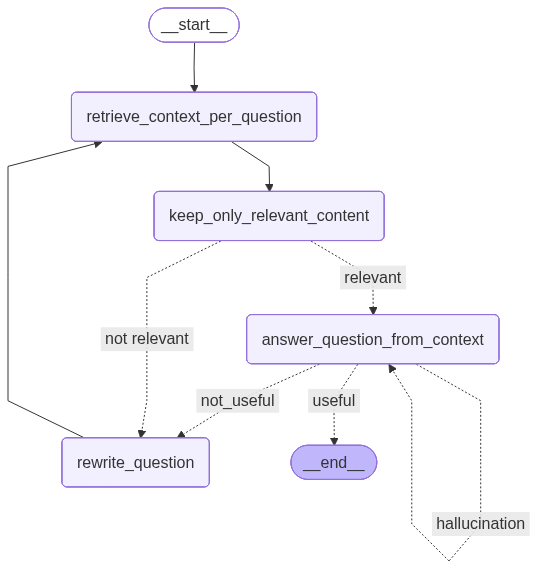

In [79]:
# -----------------------------------------------
# Construccion del Grafo de Respuesta con Recuperacion Cualitativa
# -----------------------------------------------

# Definir el estado para el grafo de flujo de trabajo
class QualitativeRetievalAnswerGraphState(TypedDict):
    question: str
    context: str
    answer: str

# Crear el objeto de grafo de flujo de trabajo
qualitative_retrieval_answer_workflow = StateGraph(QualitativeRetievalAnswerGraphState)

# -------------------------
# Definir y Agregar Nodos del Grafo
# -------------------------
# Cada nodo representa una funcion en el pipeline

# Nodo: Recuperar contexto para la pregunta desde los almacenes vectoriales
qualitative_retrieval_answer_workflow.add_node(
    "retrieve_context_per_question", retrieve_context_per_question
)

# Nodo: Usar LLM para conservar solo el contenido relevante del contexto recuperado
qualitative_retrieval_answer_workflow.add_node(
    "keep_only_relevant_content", keep_only_relevant_content
)

# Nodo: Reescribir la pregunta para mejor recuperacion si es necesario
qualitative_retrieval_answer_workflow.add_node(
    "rewrite_question", rewrite_question
)

# Nodo: Responder la pregunta a partir del contexto relevante usando LLM
qualitative_retrieval_answer_workflow.add_node(
    "answer_question_from_context", answer_question_from_context
)

# -------------------------
# Construir los Bordes del Flujo de Trabajo
# -------------------------

# Establecer el punto de entrada del flujo de trabajo
qualitative_retrieval_answer_workflow.set_entry_point("retrieve_context_per_question")

# Borde: Despues de recuperar contexto, filtrar para conservar solo contenido relevante
qualitative_retrieval_answer_workflow.add_edge(
    "retrieve_context_per_question", "keep_only_relevant_content"
)

# Borde Condicional: Despues de filtrar, verificar si el contenido es relevante
# Si es relevante, responder la pregunta; si no, reescribir la pregunta
qualitative_retrieval_answer_workflow.add_conditional_edges(
    "keep_only_relevant_content",
    is_relevant_content,
    {
        "relevant": "answer_question_from_context",
        "not relevant": "rewrite_question"
    },
)

# Borde: Despues de reescribir la pregunta, recuperar contexto nuevamente
qualitative_retrieval_answer_workflow.add_edge(
    "rewrite_question", "retrieve_context_per_question"
)

# Borde Condicional: Despues de responder, calificar la respuesta
# Si es alucinacion, intentar responder de nuevo; si no es util, reescribir pregunta; si es util, terminar
qualitative_retrieval_answer_workflow.add_conditional_edges(
    "answer_question_from_context",
    grade_generation_v_documents_and_question,
    {
        "hallucination": "answer_question_from_context",
        "not_useful": "rewrite_question",
        "useful": END
    },
)

# Compilar el grafo de flujo de trabajo en una aplicacion ejecutable
qualitative_retrieval_answer_retrival_app = qualitative_retrieval_answer_workflow.compile()

# Mostrar el grafo de flujo de trabajo como un diagrama Mermaid
display(
    Image(
        qualitative_retrieval_answer_retrival_app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

Para tareas mas complejas, en las que la pregunta no se responde solamente con una recuperacion directa, el notebook introduce subgrafos y un agente que planea, ejecuta herramientas y replantea la busqueda. Esta parte es util para aprender que RAG tambien puede organizarse como un proceso iterativo.


### Agregamos una funcion que verifica que el contenido destilado este fundamentado en el contexto original


In [80]:
# --- Funcion: Verificar si el Contenido Destilado esta Fundamentado en el Contexto Original ---

# Plantilla de prompt para que el LLM determine la fundamentacion.
# CORREGIDO: Prompt en español, contextualizado para manual de convivencia.
is_distilled_content_grounded_on_content_prompt_template = """
Recibes un contenido destilado: {distilled_content} y el contexto original: {original_context}.
Ambos provienen de un manual de convivencia de un conjunto residencial.
Debes determinar si el contenido destilado esta fundamentado en el contexto original.
Si el contenido destilado esta fundamentado en el contexto original, establece el campo grounded como true (verdadero).
Si el contenido destilado NO esta fundamentado en el contexto original, establece el campo grounded como false (falso).
Considera que el contenido destilado es una extraccion o filtrado del contexto original, por lo que debe ser un subconjunto fiel.
{format_instructions}
"""

# Esquema de salida para la respuesta del LLM
class IsDistilledContentGroundedOnContent(BaseModel):
    grounded: bool = Field(
        description="Si el contenido destilado esta fundamentado en el contexto original."
    )
    explanation: str = Field(
        description="Una explicacion de por que el contenido destilado esta o no fundamentado en el contexto original."
    )

# Parseador JSON para el esquema de salida
is_distilled_content_grounded_on_content_json_parser = JsonOutputParser(
    pydantic_object=IsDistilledContentGroundedOnContent
)

# Crear el objeto prompt para el LLM
is_distilled_content_grounded_on_content_prompt = PromptTemplate(
    template=is_distilled_content_grounded_on_content_prompt_template,
    input_variables=["distilled_content", "original_context"],
    partial_variables={
        "format_instructions": is_distilled_content_grounded_on_content_json_parser.get_format_instructions()
    },
)

# Inicializar el LLM para esta tarea
is_distilled_content_grounded_on_content_llm = ChatGoogleGenerativeAI(
    temperature=0,
    model="gemini-2.5-pro",
    google_api_key=google_api_key,
    max_tokens=4000
)

# Componer la cadena: prompt -> LLM -> parseador de salida
is_distilled_content_grounded_on_content_chain = (
    is_distilled_content_grounded_on_content_prompt
    | is_distilled_content_grounded_on_content_llm
    | is_distilled_content_grounded_on_content_json_parser
)

def is_distilled_content_grounded_on_content(state):
    """
    Determina si el contenido destilado esta fundamentado en el contexto original.

    Args:
        state (dict): Un diccionario que contiene:
            - "relevant_context": El contenido destilado.
            - "context": El contexto original.

    Returns:
        str: "grounded on the original context" si esta fundamentado, de lo contrario "not grounded on the original context".
    """
    pprint("--------------------")
    print("Determinando si el contenido destilado esta fundamentado en el contexto original...")

    distilled_content = state["relevant_context"]
    original_context = state["context"]

    input_data = {
        "distilled_content": distilled_content,
        "original_context": original_context
    }

    # Invocar la cadena LLM para verificar fundamentacion
    output = is_distilled_content_grounded_on_content_chain.invoke(input_data)
    grounded = output["grounded"]

    if grounded:
        print("El contenido destilado SI esta fundamentado en el contexto original.")
        return "grounded on the original context"
    else:
        print("El contenido destilado NO esta fundamentado en el contexto original.")
        return "not grounded on the original context"

### Crear funciones para cada tipo de recuperacion


In [81]:
# -----------------------------------------------------------
# Funciones de Recuperacion para Diferentes Tipos de Contexto
# -----------------------------------------------------------

def retrieve_chunks_context_per_question(state):
    """
    Recupera contexto relevante para una pregunta dada desde los fragmentos del libro.

    Args:
        state (dict): Un diccionario que contiene la pregunta a responder, con clave "question".

    Returns:
        dict: Un diccionario con claves:
            - "context": Cadena de contexto agregado de fragmentos relevantes del libro.
            - "question": La pregunta original.
    """
    print("Recuperando fragmentos relevantes...")
    question = state["question"]
    # Recuperar fragmentos relevantes del libro usando el recuperador
    docs = chunks_query_retriever.invoke(question)
    # Concatenar el contenido de los documentos recuperados
    context = " ".join(doc.page_content for doc in docs)
    context = escape_quotes(context)
    return {"context": context, "question": question}

def retrieve_summaries_context_per_question(state):
    """
    Recupera contexto relevante para una pregunta dada desde los resumenes de capitulos.

    Args:
        state (dict): Un diccionario que contiene la pregunta a responder, con clave "question".

    Returns:
        dict: Un diccionario con claves:
            - "context": Cadena de contexto agregado de resumenes de capitulos relevantes.
            - "question": La pregunta original.
    """
    print("Recuperando resumenes de capitulos relevantes...")
    question = state["question"]
    # Recuperar resumenes de capitulos relevantes usando el recuperador
    docs_summaries = chapter_summaries_query_retriever.invoke(question)
    # Concatenar el contenido de los resumenes recuperados, incluyendo cita del capitulo
    context_summaries = " ".join(
        f"{doc.page_content} (Capitulo {doc.metadata['chapter']})" for doc in docs_summaries
    )
    context_summaries = escape_quotes(context_summaries)
    return {"context": context_summaries, "question": question}

def retrieve_book_quotes_context_per_question(state):
    """
    Recupera contexto relevante para una pregunta dada desde las citas del libro.

    Args:
        state (dict): Un diccionario que contiene la pregunta a responder, con clave "question".

    Returns:
        dict: Un diccionario con claves:
            - "context": Cadena de contexto agregado de citas relevantes del libro.
            - "question": La pregunta original.
    """
    question = state["question"]
    print("Recuperando citas relevantes del libro...")
    # Recuperar citas relevantes del libro usando el recuperador
    docs_book_quotes = book_quotes_query_retriever.invoke(question)
    # Concatenar el contenido de las citas recuperadas
    book_quotes = " ".join(doc.page_content for doc in docs_book_quotes)
    book_quotes_context = escape_quotes(book_quotes)
    return {"context": book_quotes_context, "question": question}

## Crear subgrafos para cada tipo de recuperacion


### El primer subgrafo sera para recuperacion y destilacion de la informacion relevante con algunas modificaciones


In [82]:
class QualitativeRetrievalGraphState(TypedDict):
    """
    Representa el estado del grafo de recuperacion cualitativa.

    Atributos:
        question (str): La pregunta de entrada a responder.
        context (str): El contexto recuperado de la fuente (ej., fragmentos del libro, resumenes o citas).
        relevant_context (str): El contexto destilado o filtrado que es mas relevante para la pregunta.
    """
    question: str
    context: str
    relevant_context: str

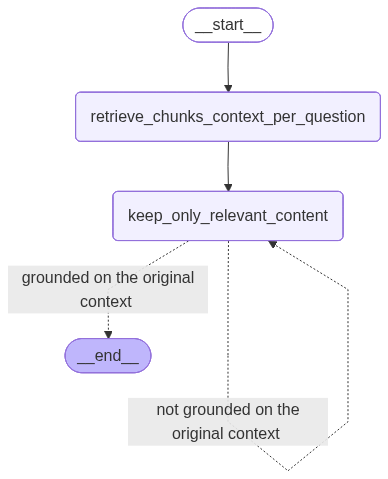

In [83]:
# -----------------------------------------------------------
# Construccion del Grafo de Flujo de Trabajo de Recuperacion Cualitativa de Fragmentos
# -----------------------------------------------------------

# 1. Crear el objeto de grafo de flujo de trabajo con el tipo de estado apropiado
qualitative_chunks_retrieval_workflow = StateGraph(QualitativeRetrievalGraphState)

# 2. Definir y agregar nodos al grafo
# Nodo: Recuperar contexto relevante de los fragmentos del libro para la pregunta
qualitative_chunks_retrieval_workflow.add_node(
    "retrieve_chunks_context_per_question",
    retrieve_chunks_context_per_question
)
# Nodo: Usar LLM para conservar solo el contenido relevante del contexto recuperado
qualitative_chunks_retrieval_workflow.add_node(
    "keep_only_relevant_content",
    keep_only_relevant_content
)

# 3. Establecer el punto de entrada del flujo de trabajo
qualitative_chunks_retrieval_workflow.set_entry_point("retrieve_chunks_context_per_question")

# 4. Agregar bordes para definir el flujo de trabajo
# Despues de recuperar contexto, filtrar para conservar solo contenido relevante
qualitative_chunks_retrieval_workflow.add_edge(
    "retrieve_chunks_context_per_question",
    "keep_only_relevant_content"
)

# Borde condicional: Despues de filtrar, verificar si el contenido destilado esta fundamentado en el contexto original
# Si esta fundamentado, terminar; si no, repetir el filtrado
qualitative_chunks_retrieval_workflow.add_conditional_edges(
    "keep_only_relevant_content",
    is_distilled_content_grounded_on_content,
    {
        "grounded on the original context": END,
        "not grounded on the original context": "keep_only_relevant_content"
    },
)

# 5. Compilar el grafo de flujo de trabajo en una aplicacion ejecutable
qualitative_chunks_retrieval_workflow_app = qualitative_chunks_retrieval_workflow.compile()

# 6. Mostrar el grafo de flujo de trabajo como un diagrama Mermaid
display(
    Image(
        qualitative_chunks_retrieval_workflow_app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

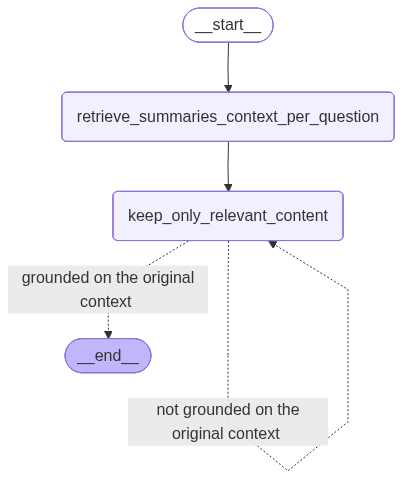

In [84]:
# -----------------------------------------------------------
# Construccion del Grafo de Flujo de Trabajo de Recuperacion Cualitativa de Resumenes
# -----------------------------------------------------------

# 1. Crear el objeto de grafo de flujo de trabajo con el tipo de estado apropiado
qualitative_summaries_retrieval_workflow = StateGraph(QualitativeRetrievalGraphState)

# 2. Definir y agregar nodos al grafo
# Nodo: Recuperar contexto relevante de los resumenes de capitulos para la pregunta
qualitative_summaries_retrieval_workflow.add_node(
    "retrieve_summaries_context_per_question",
    retrieve_summaries_context_per_question
)
# Nodo: Usar LLM para conservar solo el contenido relevante del contexto recuperado
qualitative_summaries_retrieval_workflow.add_node(
    "keep_only_relevant_content",
    keep_only_relevant_content
)

# 3. Establecer el punto de entrada del flujo de trabajo
qualitative_summaries_retrieval_workflow.set_entry_point("retrieve_summaries_context_per_question")

# 4. Agregar bordes para definir el flujo de trabajo
# Despues de recuperar contexto, filtrar para conservar solo contenido relevante
qualitative_summaries_retrieval_workflow.add_edge(
    "retrieve_summaries_context_per_question",
    "keep_only_relevant_content"
)

# Borde condicional: Despues de filtrar, verificar si el contenido destilado esta fundamentado en el contexto original
# Si esta fundamentado, terminar; si no, repetir el filtrado
qualitative_summaries_retrieval_workflow.add_conditional_edges(
    "keep_only_relevant_content",
    is_distilled_content_grounded_on_content,
    {
        "grounded on the original context": END,
        "not grounded on the original context": "keep_only_relevant_content"
    },
)

# 5. Compilar el grafo de flujo de trabajo en una aplicacion ejecutable
qualitative_summaries_retrieval_workflow_app = qualitative_summaries_retrieval_workflow.compile()

# 6. Mostrar el grafo de flujo de trabajo como un diagrama Mermaid
display(
    Image(
        qualitative_summaries_retrieval_workflow_app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

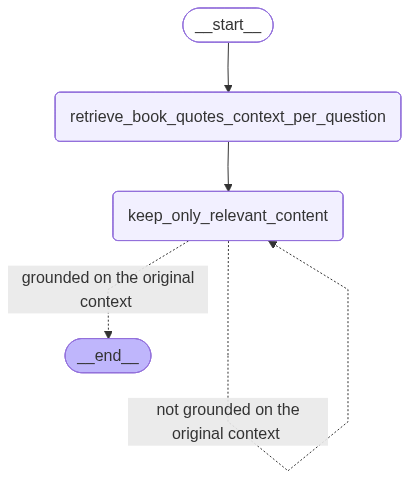

In [85]:
# -----------------------------------------------------------
# Construccion del Grafo de Flujo de Trabajo de Recuperacion Cualitativa de Citas del Libro
# -----------------------------------------------------------

# 1. Crear el objeto de grafo de flujo de trabajo con el tipo de estado apropiado
qualitative_book_quotes_retrieval_workflow = StateGraph(QualitativeRetrievalGraphState)

# 2. Definir y agregar nodos al grafo
# Nodo: Recuperar contexto relevante de las citas del libro para la pregunta
qualitative_book_quotes_retrieval_workflow.add_node(
    "retrieve_book_quotes_context_per_question",
    retrieve_book_quotes_context_per_question
)
# Nodo: Usar LLM para conservar solo el contenido relevante del contexto recuperado
qualitative_book_quotes_retrieval_workflow.add_node(
    "keep_only_relevant_content",
    keep_only_relevant_content
)

# 3. Establecer el punto de entrada del flujo de trabajo
qualitative_book_quotes_retrieval_workflow.set_entry_point("retrieve_book_quotes_context_per_question")

# 4. Agregar bordes para definir el flujo de trabajo
# Despues de recuperar contexto, filtrar para conservar solo contenido relevante
qualitative_book_quotes_retrieval_workflow.add_edge(
    "retrieve_book_quotes_context_per_question",
    "keep_only_relevant_content"
)

# Borde condicional: Despues de filtrar, verificar si el contenido destilado esta fundamentado en el contexto original
# Si esta fundamentado, terminar; si no, repetir el filtrado
qualitative_book_quotes_retrieval_workflow.add_conditional_edges(
    "keep_only_relevant_content",
    is_distilled_content_grounded_on_content,
    {
        "grounded on the original context": END,
        "not grounded on the original context": "keep_only_relevant_content"
    },
)

# 5. Compilar el grafo de flujo de trabajo en una aplicacion ejecutable
qualitative_book_quotes_retrieval_workflow_app = qualitative_book_quotes_retrieval_workflow.compile()

# 6. Mostrar el grafo de flujo de trabajo como un diagrama Mermaid
display(
    Image(
        qualitative_book_quotes_retrieval_workflow_app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

### Probar los grafos de recuperacion y conservacion de contenido relevante


In [88]:
# -----------------------------------------------------------
# Inicializar el estado para el pipeline de recuperacion/respuesta
# -----------------------------------------------------------
# Este diccionario define el estado inicial para el flujo de trabajo,
# especificando la pregunta a responder.
# Modificado para evaluar el Manual de Convivencia de Amaranto Club House.
init_state = {
    "question": "¿Cuál es la velocidad máxima permitida para los vehículos y motos dentro del condominio?"
}

In [89]:
# -----------------------------------------------------------
# Probar el flujo de trabajo de recuperacion de fragmentos del libro
# -----------------------------------------------------------

# Transmitir las salidas desde qualitative_chunks_retrieval_workflow_app
# para el estado inicial dado (init_state contiene la pregunta a responder).
for output in qualitative_chunks_retrieval_workflow_app.stream(init_state):
    # Iterar a traves de los elementos de salida (nombre del nodo, valor)
    for _, value in output.items():
        pass  # La variable value contendra el ultimo estado despues de cada ejecucion de nodo
    pprint("--------------------")  # Imprimir un separador para claridad entre pasos

# Despues de que el flujo de trabajo termina, imprimir el contexto relevante final extraido
print(f'Contexto relevante: {value["relevant_context"]}')

Recuperando fragmentos relevantes...
'--------------------'
Conservando solo el contenido relevante...
'--------------------'
'--------------------'
Determinando si el contenido destilado esta fundamentado en el contexto original...
El contenido destilado NO esta fundamentado en el contexto original.
'--------------------'
Conservando solo el contenido relevante...
'--------------------'
'--------------------'
Determinando si el contenido destilado esta fundamentado en el contexto original...
El contenido destilado NO esta fundamentado en el contexto original.
'--------------------'
Conservando solo el contenido relevante...
'--------------------'
'--------------------'
Determinando si el contenido destilado esta fundamentado en el contexto original...
El contenido destilado NO esta fundamentado en el contexto original.
'--------------------'
Conservando solo el contenido relevante...
'--------------------'
'--------------------'
Determinando si el contenido destilado esta fundamentado

KeyboardInterrupt: 

In [ ]:
# -----------------------------------------------------------
# Probar el flujo de trabajo de recuperación de resúmenes del Manual de Convivencia
# -----------------------------------------------------------

# Transmitir las salidas desde qualitative_summaries_retrieval_workflow_app
# para el estado inicial dado (init_state contiene la pregunta sobre el reglamento).
for output in qualitative_summaries_retrieval_workflow_app.stream(init_state):
    # Iterar a través de los elementos de salida (nombre del nodo, valor)
    for _, value in output.items():
        pass  # La variable 'value' contendrá el último estado después de cada ejecución de nodo
    pprint("--------------------")  # Imprimir un separador para claridad entre pasos

# Después de que el flujo de trabajo termina, imprimir el contexto relevante final extraído del manual
print(f'Contexto relevante extraído: {value["relevant_context"]}')

In [ ]:
# -----------------------------------------------------------
# Probar el flujo de trabajo de recuperación de artículos específicos del manual
# -----------------------------------------------------------

# Transmitir las salidas desde qualitative_book_quotes_retrieval_workflow_app
# para el estado inicial dado (init_state contiene la pregunta sobre el reglamento).
for output in qualitative_book_quotes_retrieval_workflow_app.stream(init_state):
    # Iterar a través de los elementos de salida (nombre del nodo, valor)
    for _, value in output.items():
        pass  # La variable 'value' contendrá el último estado después de cada ejecución de nodo
    pprint("--------------------")  # Imprimir un separador para claridad entre pasos

# Después de que el flujo de trabajo termina, imprimir el contexto de artículos extraído
print(f'Contexto relevante de artículos extraído: {value["relevant_context"]}')

### Agregar una version mas corta de la verificacion de respuesta, verificando solo si esta fundamentada en el contexto


In [ ]:
def is_answer_grounded_on_context(state):
    """
    Determina si la respuesta generada está estrictamente fundamentada en el contexto 
    extraído del Manual de Convivencia (evitando así alucinaciones normativas).

    Argumentos:
        state (dict): El estado actual del flujo en LangGraph que contiene:
            - "context": El texto original extraído de la base de datos FAISS.
            - "answer": La respuesta analítica que generó el LLM en el paso anterior.

    Retorna:
        str: "hallucination" si la respuesta inventa normas o no tiene sustento en el PDF.
             "grounded on context" si la respuesta está plenamente respaldada por el reglamento.
    """
    print("\n[Auditoría] Verificando si la respuesta está fundamentada en las normas del Manual...")

    # Extraer de manera segura el contexto y la respuesta del estado actual del grafo
    context = state.get("context", "")
    answer = state.get("answer", "")

    # Invocar la cadena de verificación de hechos (fact-checking)
    result = is_grounded_on_facts_chain.invoke({"context": context, "answer": answer})
    
    grounded_on_facts = False
    if result is not None and hasattr(result, 'grounded_on_facts'):
        grounded_on_facts = result.grounded_on_facts

    # Evaluar el veredicto del validador para definir la ruta de ejecución o métrica
    if not grounded_on_facts:
        print("⚠️ Alerta: La respuesta contiene alucinaciones o datos no presentes en el Manual de Convivencia.")
        return "hallucination"
    else:
        print("✅ Éxito: La respuesta está perfectamente fundamentada en los hechos reales de Amaranto Club House.")
        return "grounded on context"

### El ultimo subgrafo sera un componente que responde una pregunta dado un contexto, sin alucinaciones


In [ ]:
# -----------------------------------------------
# Construccion del Grafo de Flujo de Trabajo de Respuesta Cualitativa
# -----------------------------------------------

# Definir el estado para el grafo de flujo de trabajo de respuesta
class QualitativeAnswerGraphState(TypedDict):
    """
    Representa el estado del grafo de respuesta cualitativa.

    Atributos:
        question (str): La pregunta de entrada a responder.
        context (str): El contexto usado para responder la pregunta.
        answer (str): La respuesta generada a la pregunta.
    """
    question: str
    context: str
    answer: str

# Crear el objeto de grafo de flujo de trabajo
qualitative_answer_workflow = StateGraph(QualitativeAnswerGraphState)

# -------------------------
# Definir y Agregar Nodos del Grafo
# -------------------------

# Nodo: Responder la pregunta a partir del contexto proporcionado usando LLM
qualitative_answer_workflow.add_node(
    "answer_question_from_context",
    answer_question_from_context
)

# -------------------------
# Construir los Bordes del Flujo de Trabajo
# -------------------------

# Establecer el punto de entrada del flujo de trabajo
qualitative_answer_workflow.set_entry_point("answer_question_from_context")

# Borde Condicional: Despues de responder, verificar si la respuesta esta fundamentada en el contexto
# Si es alucinacion, intentar responder de nuevo; si esta fundamentada, terminar
qualitative_answer_workflow.add_conditional_edges(
    "answer_question_from_context",
    is_answer_grounded_on_context,
    {
        "hallucination": "answer_question_from_context",
        "grounded on context": END
    }
)

# Compilar el grafo de flujo de trabajo en una aplicacion ejecutable
qualitative_answer_workflow_app = qualitative_answer_workflow.compile()

# Mostrar el grafo de flujo de trabajo como un diagrama Mermaid
display(
    Image(
        qualitative_answer_workflow_app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

### Probar el grafo de respuesta a partir de pregunta


In [ ]:
# -----------------------------------------------
# Probar el grafo de flujo de trabajo de respuesta cualitativa
# -----------------------------------------------

# Definir la pregunta y el contexto para la prueba
question = "who is harry?"  # La pregunta a responder
context = "Harry Potter is a cat."  # El contexto para responder la pregunta

# Inicializar el estado para el flujo de trabajo
init_state = {
    "question": question,
    "context": context
}

# Transmitir las salidas desde qualitative_answer_workflow_app
# Esto ejecutara cada nodo en el flujo de trabajo paso a paso
for output in qualitative_answer_workflow_app.stream(init_state):
    # Iterar a traves de los elementos de salida (nombre del nodo, valor)
    for _, value in output.items():
        pass  # La variable value contiene el ultimo estado despues de cada ejecucion de nodo
    pprint("--------------------")  # Imprimir un separador para claridad entre pasos

# Despues de que el flujo de trabajo termina, imprimir la respuesta final generada por el flujo de trabajo
print(f'Respuesta: {value["answer"]}')

# Componentes del pipeline avanzado


### El estado de cada paso del grafo debe estar en esta estructura:


In [ ]:
from typing import TypedDict, List, Dict

class PlanExecute(TypedDict):
    """
    Representa el estado en cada paso de la ejecucion del pipeline de planificacion.

    Atributos:
        curr_state (str): El estado o estatus actual de la ejecucion.
        question (str): La pregunta original del usuario.
        anonymized_question (str): La version anonimizada de la pregunta (entidades reemplazadas con variables).
        query_to_retrieve_or_answer (str): La consulta a utilizar para recuperacion o respuesta.
        plan (List[str]): El plan actual como una lista de pasos a ejecutar.
        past_steps (List[str]): Lista de pasos que ya se han ejecutado.
        mapping (dict): Mapeo de variables anonimizadas a entidades nombradas originales.
        curr_context (str): El contexto actual utilizado para responder o recuperar.
        aggregated_context (str): El contexto acumulado de pasos anteriores.
        tool (str): La herramienta o metodo utilizado para el paso actual (ej., recuperacion, respuesta).
        response (str): La respuesta o salida generada en este paso.
    """
    curr_state: str
    question: str
    anonymized_question: str
    query_to_retrieve_or_answer: str
    plan: List[str]
    past_steps: List[str]
    mapping: Dict[str, str]
    curr_context: str
    aggregated_context: str
    tool: str
    response: str

### Definir el nodo Plan - construye un plan compuesto de pasos, sobre como abordar una pregunta


In [ ]:
from typing import List
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field

# -----------------------------------------------
# Componente de Planificacion para Respuesta a Preguntas en Multiples Pasos
# -----------------------------------------------


# Definir el esquema de salida para el plan
class Plan(BaseModel):
    """
    Representa un plan paso a paso para responder una pregunta dada.
    Atributos:
        steps (List[str]): Lista ordenada de pasos a seguir.
    """
    steps: List[str] = Field(
        description="Diferentes pasos a seguir, deben estar en orden"
    )

# Plantilla de prompt para generar un plan a partir de una pregunta.
# CORREGIDO: Prompt completamente en español, orientado a un manual de convivencia de conjunto residencial.
# El planificador ahora sabe que debe buscar en un documento PDF (el manual), NO en internet o fuentes externas.
# Esto evita que genere pasos como "Research the function of 'X' using official websites"
# que causan que el filtro elimine el texto real del PDF.
planner_prompt = """
Para la siguiente consulta: {question}, elabora un plan simple paso a paso para encontrar la respuesta.

CONTEXTO IMPORTANTE: Estas trabajando con un MANUAL DE CONVIVENCIA de un conjunto residencial colombiano.
La unica fuente de informacion disponible es este documento PDF. NO puedes buscar en internet, paginas web,
articulos academicos, manuales de productos ni ninguna otra fuente externa.

Este plan debe consistir en tareas individuales que, si se ejecutan correctamente, produciran la respuesta correcta.
No agregues pasos superfluos.
El resultado del paso final debe ser la respuesta definitiva.
Asegurate de que cada paso tenga toda la informacion necesaria - no omitas pasos.

Cada paso debe estar formulado como una consulta de busqueda en español, usando terminos legales/normativos
tipicos de manuales de convivencia colombianos (articulo, norma, prohibicion, obligacion, sancion, etc.).
"""

planner_prompt = PromptTemplate(
    template=planner_prompt,
    input_variables=["question"],
)

# Inicializar el LLM para planificacion (usando GPT-4o)
planner_llm = ChatOpenAI(
    temperature=0,
    model_name="gpt-4o",
    max_tokens=2000
)

# Componer la cadena de planificacion: prompt -> LLM -> salida estructurada
planner = planner_prompt | planner_llm.with_structured_output(Plan, method="function_calling")

### Una funcion para desglosar cada tarea para recuperar o responder


In [ ]:
# -----------------------------------------------------------
# Cadena para Refinar un Plan en Pasos Ejecutables para Recuperacion/Respuesta
# -----------------------------------------------------------

# Plantilla de prompt para refinar un plan para que cada paso sea ejecutable mediante una operacion de recuperacion o respuesta.
# CORREGIDO: Prompt en español.
break_down_plan_prompt_template = """
Recibes un plan {plan} que contiene una serie de pasos a seguir para responder una consulta.
Debes revisar el plan y refinarlo de acuerdo con estas reglas:
1. Cada paso debe ser ejecutable mediante una de las siguientes opciones:
    i. Recuperar informacion relevante desde un almacen vectorial de fragmentos del manual de convivencia.
    ii. Recuperar informacion relevante desde un almacen vectorial de resumenes de capitulos del manual.
    iii. Recuperar informacion relevante desde un almacen vectorial de citas del manual.
    iv. Responder una pregunta a partir de un contexto dado.
2. Cada paso debe contener toda la informacion necesaria para ejecutarlo.

Genera el plan refinado.
"""

# Crear un PromptTemplate para el LLM
break_down_plan_prompt = PromptTemplate(
    template=break_down_plan_prompt_template,
    input_variables=["plan"],
)

# Inicializar el LLM para desglose de plan (usando GPT-4o)
break_down_plan_llm = ChatOpenAI(
    temperature=0,
    model_name="gpt-4o",
    max_tokens=2000
)

# Componer la cadena: prompt -> LLM -> salida estructurada (Plan)
break_down_plan_chain = break_down_plan_prompt | break_down_plan_llm.with_structured_output(Plan, method="function_calling")

### Ejemplo de como usar el planificador


In [ ]:
# -----------------------------------------------------------
# Ejemplo: Como Usar el Planificador y Refinar el Plan
# -----------------------------------------------------------

# 1. Definir la pregunta a responder
question = {"question": "¿Como vencio el protagonista al villano?"}

# 2. Generar un plan paso a paso para responder la pregunta usando la cadena planificadora
my_plan = planner.invoke(question)
print("Plan Inicial:")
print(my_plan)

# 3. Refinar el plan para que cada paso sea ejecutable mediante una operacion de recuperacion o respuesta
refined_plan = break_down_plan_chain.invoke({"plan": my_plan.steps})
print("\nPlan Refinado:")
print(refined_plan)

### Dada la pregunta original, el plan actual, los pasos anteriores y la informacion agregada hasta ahora, actualizar el plan


In [ ]:
# -----------------------------------------------------------
# Replanificador: Actualizar Plan Basado en el Progreso y Contexto Agregado
# -----------------------------------------------------------

# Definir un modelo Pydantic para los posibles resultados de la accion de replanificacion
class ActPossibleResults(BaseModel):
    """
    Representa los posibles resultados de la accion de replanificacion.

    Atributos:
        plan (Plan): El plan actualizado a seguir en el futuro.
        explanation (str): Explicacion de la accion tomada o el razonamiento detras de la actualizacion del plan.
    """
    plan: Plan = Field(description="Plan a seguir en el futuro.")
    explanation: str = Field(description="Explicacion de la accion.")

# Crear un parseador de salida JSON para el esquema ActPossibleResults
act_possible_results_parser = JsonOutputParser(pydantic_object=ActPossibleResults)

# Plantilla de prompt para replanificacion, instruyendo al LLM a actualizar el plan basado en el estado actual.
# CORREGIDO: Prompt en español, orientado al manual de convivencia.
replanner_prompt_template = """
Para el siguiente objetivo, elabora un plan simple paso a paso sobre como encontrar la respuesta.
Este plan debe consistir en tareas individuales que, si se ejecutan correctamente, produciran la respuesta correcta.
No agregues pasos superfluos.
El resultado del paso final debe ser la respuesta definitiva.
Asegurate de que cada paso tenga toda la informacion necesaria - no omitas pasos.

RECUERDA: La unica fuente de informacion es un manual de convivencia de un conjunto residencial colombiano.
NO puedes buscar en internet, sitios web oficiales ni fuentes externas.

Asume que la respuesta aun NO se ha encontrado y necesitas actualizar el plan en consecuencia,
por lo que el plan nunca debe estar vacio.

Tu objetivo era este:
{question}

Tu plan original era este:
{plan}

Hasta ahora has realizado los siguientes pasos:
{past_steps}

Ya tienes el siguiente contexto:
{aggregated_context}

Actualiza tu plan en consecuencia. Si se necesitan mas pasos, completa el plan solo con esos pasos.
No devuelvas pasos realizados anteriormente como parte del plan.

El formato es JSON, escapa comillas y saltos de linea.

{format_instructions}
"""

# Crear un objeto PromptTemplate para el replanificador
replanner_prompt = PromptTemplate(
    template=replanner_prompt_template,
    input_variables=["question", "plan", "past_steps", "aggregated_context"],
    partial_variables={"format_instructions": act_possible_results_parser.get_format_instructions()},
)

# Inicializar el LLM para replanificacion (usando GPT-4o)
replanner_llm = ChatOpenAI(
    temperature=0,
    model_name="gpt-4o",
    max_tokens=2000
)

# Componer la cadena replanificadora: prompt -> LLM -> parseador de salida
replanner = replanner_prompt | replanner_llm | act_possible_results_parser

### Definir el manejador de tareas - decide si usar el primer subgrafo o el segundo subgrafo para manejar cada tarea del plan


In [ ]:
# -----------------------------------------------------------
# Manejador de Tareas: Decidir Que Herramienta Usar para Cada Tarea
# -----------------------------------------------------------

# Plantilla de prompt para el LLM manejador de tareas.
# CORREGIDO: Prompt en español, contextualizado para el manual de convivencia.
tasks_handler_prompt_template = """
Eres un manejador de tareas que recibe una tarea {curr_task} y debe decidir que herramienta usar para ejecutarla.
El contexto de trabajo es un MANUAL DE CONVIVENCIA de un conjunto residencial colombiano.

Tienes las siguientes herramientas a tu disposicion:
Herramienta A: una herramienta que recupera informacion relevante desde un almacen vectorial de fragmentos del manual basado en una consulta dada.
- usa la Herramienta A cuando consideres que la tarea actual debe buscar informacion en los fragmentos del manual.
Herramienta B: una herramienta que recupera informacion relevante desde un almacen vectorial de resumenes de capitulos del manual basado en una consulta dada.
- usa la Herramienta B cuando consideres que la tarea actual debe buscar informacion en los resumenes de capitulos.
Herramienta C: una herramienta que recupera informacion relevante desde un almacen vectorial de citas del manual basado en una consulta dada.
- usa la Herramienta C cuando consideres que la tarea actual debe buscar informacion en las citas del manual.
Herramienta D: una herramienta que responde una pregunta a partir de un contexto dado.
- usa la Herramienta D SOLAMENTE cuando la tarea actual pueda responderse con el contexto agregado {aggregated_context}

Tambien recibes la ultima herramienta utilizada {last_tool}
si {last_tool} fue retrieve_chunks, usa otras herramientas distintas a la Herramienta A.

Tambien tienes los pasos anteriores {past_steps} que puedes usar para tomar decisiones y entender el contexto de la tarea.
Tambien tienes la pregunta inicial del usuario {question} que puedes usar para tomar decisiones y entender el contexto de la tarea.
Si decides usar las Herramientas A, B o C, genera la consulta a utilizar para la herramienta y tambien la herramienta correspondiente.
Si decides usar la Herramienta D, genera la pregunta a utilizar para la herramienta, el contexto, y tambien que la herramienta a usar es la Herramienta D.
"""

# Esquema de salida para el manejador de tareas
class TaskHandlerOutput(BaseModel):
    """
    Esquema de salida para el manejador de tareas.
    - query: La consulta a recuperar del almacen vectorial, o la pregunta que debe responderse a partir del contexto.
    - curr_context: El contexto en el que basarse para responder la consulta.
    - tool: La herramienta a utilizar; debe ser una de 'retrieve_chunks', 'retrieve_summaries', 'retrieve_quotes', o 'answer_from_context'.
    """
    query: str = Field(description="La consulta a recuperar del almacen vectorial, o la pregunta que debe responderse a partir del contexto.")
    curr_context: str = Field(description="El contexto en el que basarse para responder la consulta.")
    tool: str = Field(description="La herramienta a utilizar debe ser: retrieve_chunks, retrieve_summaries, retrieve_quotes, o answer_from_context.")

# Crear el objeto prompt para el manejador de tareas
task_handler_prompt = PromptTemplate(
    template=tasks_handler_prompt_template,
    input_variables=["curr_task", "aggregated_context", "last_tool", "past_steps", "question"],
)

# Inicializar el LLM para el manejador de tareas (usando GPT-4o)
task_handler_llm = ChatOpenAI(
    temperature=0,
    model_name="gpt-4o",
    max_tokens=2000
)

# Componer la cadena del manejador de tareas: prompt -> LLM -> salida estructurada
task_handler_chain = task_handler_prompt | task_handler_llm.with_structured_output(TaskHandlerOutput, method="function_calling")

### Para generar un plan general, sin sesgos basados en conocimiento previo de ningun LLM, anonimizamos la pregunta de entrada primero y mapeamos las entidades nombradas a variables


In [ ]:
# -----------------------------------------------------------
# Cadena de Anonimizacion de Preguntas: Reemplazar Entidades Nombradas con Variables
# -----------------------------------------------------------

# Definir un modelo Pydantic para la salida de pregunta anonimizada
class AnonymizeQuestion(BaseModel):
  """
  Esquema de salida para la pregunta anonimizada.
  Atributos:
    anonymized_question (str): La pregunta con entidades nombradas reemplazadas por variables.
    mapping (dict): Mapeo de variables a entidades nombradas originales.
    explanation (str): Explicacion del proceso de anonimizacion.
  """
  anonymized_question: str = Field(description="Pregunta anonimizada.")
  mapping: dict = Field(description="Mapeo de entidades nombradas originales a variables.")
  explanation: str = Field(description="Explicacion de la accion.")

# Crear un parseador de salida JSON para el esquema AnonymizeQuestion
anonymize_question_parser = JsonOutputParser(pydantic_object=AnonymizeQuestion)

# Plantilla de prompt para que el LLM anonimice preguntas
anonymize_question_prompt_template = """
Eres un anonimizador de preguntas. La entrada que recibes es una cadena que contiene varias palabras que
construyen una pregunta {question}. Tu objetivo es cambiar todas las entidades nombradas en la entrada por variables,
y recordar el mapeo de las entidades nombradas originales a las variables.
Ejemplo 1:
  si la entrada es "¿quien es harry potter?" la salida debe ser "¿quien es X?" y el mapeo debe ser {{"X": "harry potter"}}
Ejemplo 2:
  si la entrada es "¿como jugo el tipo malo con alex y rony?"
  la salida debe ser "¿como jugo el X con Y y Z?" y el mapeo debe ser {{"X": "tipo malo", "Y": "alex", "Z": "rony"}}
Debes reemplazar todas las entidades nombradas en la entrada con variables, y recordar el mapeo de las entidades nombradas originales a las variables.
Genera la pregunta anonimizada y el mapeo en un formato JSON.
{format_instructions}
"""

# Crear el objeto PromptTemplate para la tarea de anonimizacion
anonymize_question_prompt = PromptTemplate(
  template=anonymize_question_prompt_template,
  input_variables=["question"],
  partial_variables={"format_instructions": anonymize_question_parser.get_format_instructions()},
)

# Inicializar el LLM para anonimizacion (usando GPT-4o)
anonymize_question_llm = ChatOpenAI(
  temperature=0,
  model_name="gpt-4o",
  max_tokens=2000
)

# Componer la cadena de anonimizacion: prompt -> LLM -> parseador de salida
anonymize_question_chain = (
  anonymize_question_prompt
  | anonymize_question_llm
  | anonymize_question_parser
)

### Despues de que el plan se construye basado en la pregunta anonimizada, des-anonimizamos el plan usando las variables mapeadas


In [ ]:
from pydantic import BaseModel, Field
from typing import List

# -----------------------------------------------------------
# Cadena de Des-Anonimizacion del Plan: Reemplazar Variables en el Plan con Palabras Mapeadas
# -----------------------------------------------------------


class DeAnonymizePlan(BaseModel):
    """
    Esquema de salida para el plan des-anonimizado.
    Atributos:
        plan (List): Plan a seguir en el futuro, con todas las variables reemplazadas por las palabras mapeadas.
    """
    plan: List = Field(
        description="Plan a seguir en el futuro, con todas las variables reemplazadas por las palabras mapeadas."
    )

# Plantilla de prompt para des-anonimizar un plan
de_anonymize_plan_prompt_template = (
    "Recibes una lista de tareas: {plan}, donde algunas de las palabras estan reemplazadas con variables mapeadas. "
    "Tambien recibes el mapeo de esas variables a palabras {mapping}. "
    "Reemplaza todas las variables en la lista de tareas con las palabras mapeadas. "
    "Si no hay variables presentes, devuelve la lista original de tareas. "
    "En cualquier caso, solo genera la lista actualizada de tareas en un formato JSON como se describe aqui, "
    "sin ningun texto adicional aparte del JSON."
)

# Crear el objeto PromptTemplate para la tarea de des-anonimizacion
de_anonymize_plan_prompt = PromptTemplate(
    template=de_anonymize_plan_prompt_template,
    input_variables=["plan", "mapping"],
)

# Inicializar el LLM para des-anonimizacion (usando GPT-4o)
de_anonymize_plan_llm = ChatOpenAI(
    temperature=0,
    model_name="gpt-4o",
    max_tokens=2000
)

# Componer la cadena de des-anonimizacion: prompt -> LLM -> salida estructurada
de_anonymize_plan_chain = (
    de_anonymize_plan_prompt
    | de_anonymize_plan_llm.with_structured_output(DeAnonymizePlan, method="function_calling")
)

### Ejemplo de como construir un plan


In [ ]:
# -----------------------------------------------------------
# Ejemplo: Anonimizar, Planificar y Des-anonimizar una Pregunta
# -----------------------------------------------------------

# 1. Definir la pregunta a responder
state1 = {
    'question': "¿Que es Club House? \n"
}
print(f'Pregunta: {state1["question"]}')

# 2. Anonimizar la pregunta (reemplazar entidades nombradas con variables)
anonymized_question_output = anonymize_question_chain.invoke(state1)
anonymized_question = anonymized_question_output["anonymized_question"]  # La pregunta anonimizada
mapping = anonymized_question_output["mapping"]  # Mapeo de variables a entidades originales

print(f'Consulta anonimizada: {anonymized_question} \n')
print(f'Mapeo: {mapping} \n')

# 3. Generar un plan paso a paso para la pregunta anonimizada
plan = planner.invoke({"question": anonymized_question})
print(text_wrap(f'Plan: {plan.steps}'))
print("")

# 4. Des-anonimizar el plan (reemplazar variables de vuelta con entidades originales)
deanonymized_plan = de_anonymize_plan_chain.invoke({
    "plan": plan.steps,
    "mapping": mapping
})
print(text_wrap(f'Plan des-anonimizado: {deanonymized_plan.plan}'))

### Una funcion que verifica si la respuesta final ya se puede deducir, basandose en la informacion agregada


In [ ]:
# -----------------------------------------------------------
# Cadena LLM: Verificar si una Pregunta Puede Responderse Completamente a partir del Contexto
# -----------------------------------------------------------

# Definir el esquema de salida para la respuesta del LLM
class CanBeAnsweredAlready(BaseModel):
    """
    Esquema de salida para verificar si la pregunta puede responderse completamente a partir del contexto dado.
    Atributos:
        can_be_answered (bool): Si la pregunta puede responderse completamente o no basandose en el contexto dado.
    """
    can_be_answered: bool = Field(
        description="Si la pregunta puede responderse completamente o no basandose en el contexto dado."
    )

# Plantilla de prompt para que el LLM determine la respondibilidad.
# CORREGIDO: Prompt en español.
can_be_answered_already_prompt_template = """
Recibes una consulta: {question} y un contexto: {context}.
Este contexto proviene de un manual de convivencia de un conjunto residencial.
Debes determinar si la pregunta puede responderse completamente basandote solo en el contexto dado.
La unica informacion que tienes y en la que puedes confiar es el contexto que recibiste.
No tienes conocimiento previo de la pregunta o del contexto.
Si crees que la pregunta puede responderse basandose en el contexto, devuelve 'true', de lo contrario devuelve 'false'.
"""

# Crear el objeto PromptTemplate
can_be_answered_already_prompt = PromptTemplate(
    template=can_be_answered_already_prompt_template,
    input_variables=["question", "context"],
)

# Inicializar el LLM para esta tarea (usando GPT-4o)
can_be_answered_already_llm = ChatOpenAI(
    temperature=0,
    model_name="gpt-4o",
    max_tokens=2000
)

# Componer la cadena: prompt -> LLM -> salida estructurada
can_be_answered_already_chain = (
    can_be_answered_already_prompt
    | can_be_answered_already_llm.with_structured_output(CanBeAnsweredAlready, method="function_calling")
)

### Definir las funciones del grafo del pipeline sofisticado


In [ ]:
from pprint import pprint

def run_task_handler_chain(state: PlanExecute):
    """
    Ejecuta la cadena del manejador de tareas para decidir que herramienta usar para ejecutar la tarea.

    Args:
        state: El estado actual de la ejecucion del plan.

    Returns:
        El estado actualizado de la ejecucion del plan.
    """
    state["curr_state"] = "task_handler"
    print("El plan actual es:")
    print(state["plan"])
    pprint("--------------------") 

    # Inicializar past_steps si no esta presente
    if not state.get('past_steps'):
        state["past_steps"] = []
    state.setdefault("aggregated_context", "")
    state.setdefault("tool", "")

    # Obtener la tarea actual del plan
    curr_task = state["plan"][0]

    # Preparar entradas para la cadena del manejador de tareas
    inputs = {
        "curr_task": curr_task,
        "aggregated_context": state["aggregated_context"],
        "last_tool": state["tool"],
        "past_steps": state["past_steps"],
        "question": state["question"]
    }
    
    # Invocar la cadena del manejador de tareas
    output = task_handler_chain.invoke(inputs)
  
    # Actualizar estado con la tarea completada
    state["past_steps"].append(curr_task)
    state["plan"].pop(0)

    # Decidir que herramienta usar basado en la salida
    if output.tool == "retrieve_chunks":
        state["query_to_retrieve_or_answer"] = output.query
        state["tool"] = "retrieve_chunks"
    elif output.tool == "retrieve_summaries":
        state["query_to_retrieve_or_answer"] = output.query
        state["tool"] = "retrieve_summaries"
    elif output.tool == "retrieve_quotes":
        state["query_to_retrieve_or_answer"] = output.query
        state["tool"] = "retrieve_quotes"
    elif output.tool == "answer_from_context":
        state["query_to_retrieve_or_answer"] = output.query
        state["curr_context"] = output.curr_context
        state["tool"] = "answer"
    else:
        raise ValueError("Herramienta invalida generada. Debe ser 'retrieve' o 'answer_from_context'")
    return state  


def retrieve_or_answer(state: PlanExecute):
    """
    Decide si recuperar o responder la pregunta basandose en el estado actual.

    Args:
        state: El estado actual de la ejecucion del plan.

    Returns:
        Cadena indicando la herramienta elegida.
    """
    state["curr_state"] = "decide_tool"
    print("Decidiendo si recuperar o responder")
    if state["tool"] == "retrieve_chunks":
        return "chosen_tool_is_retrieve_chunks"
    elif state["tool"] == "retrieve_summaries":
        return "chosen_tool_is_retrieve_summaries"
    elif state["tool"] == "retrieve_quotes":
        return "chosen_tool_is_retrieve_quotes"
    elif state["tool"] == "answer":
        return "chosen_tool_is_answer"
    else:
        raise ValueError("Herramienta invalida generada. Debe ser 'retrieve' o 'answer_from_context'")  


def run_qualitative_chunks_retrieval_workflow(state):
    """
    Ejecuta el flujo de trabajo de recuperacion cualitativa de fragmentos.

    Args:
        state: El estado actual de la ejecucion del plan.

    Returns:
        El estado con el contexto agregado actualizado.
    """
    state["curr_state"] = "retrieve_chunks"
    print("Ejecutando el flujo de trabajo de recuperacion cualitativa de fragmentos...")
    question = state["query_to_retrieve_or_answer"]
    inputs = {"question": question}
    # Transmitir salidas desde la aplicacion de flujo de trabajo
    for output in qualitative_chunks_retrieval_workflow_app.stream(inputs):
        for _, _ in output.items():
            pass 
        pprint("--------------------")
    # Agregar el contexto recuperado
    if not state["aggregated_context"]:
        state["aggregated_context"] = ""
    # Extraer de forma segura el relevant_context del ultimo output del stream
    try:
        last_value = next(iter(output.values()))
        if isinstance(last_value, dict) and 'relevant_context' in last_value:
            state["aggregated_context"] += last_value.get('relevant_context', '')
    except (StopIteration, TypeError, AttributeError):
        pass
    return state


def run_qualitative_summaries_retrieval_workflow(state):
    """
    Ejecuta el flujo de trabajo de recuperacion cualitativa de resumenes.

    Args:
        state: El estado actual de la ejecucion del plan.

    Returns:
        El estado con el contexto agregado actualizado.
    """
    state["curr_state"] = "retrieve_summaries"
    print("Ejecutando el flujo de trabajo de recuperacion cualitativa de resumenes...")
    question = state["query_to_retrieve_or_answer"]
    inputs = {"question": question}
    for output in qualitative_summaries_retrieval_workflow_app.stream(inputs):
        for _, _ in output.items():
            pass 
        pprint("--------------------")
    if not state["aggregated_context"]:
        state["aggregated_context"] = ""
    # Extraer de forma segura el relevant_context del ultimo output del stream
    try:
        last_value = next(iter(output.values()))
        if isinstance(last_value, dict) and 'relevant_context' in last_value:
            state["aggregated_context"] += last_value.get('relevant_context', '')
    except (StopIteration, TypeError, AttributeError):
        pass
    return state


def run_qualitative_book_quotes_retrieval_workflow(state):
    """
    Ejecuta el flujo de trabajo de recuperacion cualitativa de citas del libro.

    Args:
        state: El estado actual de la ejecucion del plan.

    Returns:
        El estado con el contexto agregado actualizado.
    """
    state["curr_state"] = "retrieve_book_quotes"
    print("Ejecutando el flujo de trabajo de recuperacion cualitativa de citas del libro...")
    question = state["query_to_retrieve_or_answer"]
    inputs = {"question": question}
    for output in qualitative_book_quotes_retrieval_workflow_app.stream(inputs):
        for _, _ in output.items():
            pass 
        pprint("--------------------")
    if not state["aggregated_context"]:
        state["aggregated_context"] = ""
    # Extraer de forma segura el relevant_context del ultimo output del stream
    try:
        last_value = next(iter(output.values()))
        if isinstance(last_value, dict) and 'relevant_context' in last_value:
            state["aggregated_context"] += last_value.get('relevant_context', '')
    except (StopIteration, TypeError, AttributeError):
        pass
    return state
   

def run_qualtative_answer_workflow(state):
    """
    Ejecuta el flujo de trabajo de respuesta cualitativa.

    Args:
        state: El estado actual de la ejecucion del plan.

    Returns:
        El estado con el contexto agregado actualizado.
    """
    state["curr_state"] = "answer"
    print("Ejecutando el flujo de trabajo de respuesta cualitativa...")
    question = state["query_to_retrieve_or_answer"]
    context = state["curr_context"]
    inputs = {"question": question, "context": context}
    for output in qualitative_answer_workflow_app.stream(inputs):
        for _, _ in output.items():
            pass 
        pprint("--------------------")
    if not state["aggregated_context"]:
        state["aggregated_context"] = ""
    result = next(iter(output.values())) if isinstance(output, dict) and 'answer' not in output else output
    state["aggregated_context"] += result.get("answer", "")
    return state


def run_qualtative_answer_workflow_for_final_answer(state):
    """
    Ejecuta el flujo de respuesta cualitativa para obtener la respuesta final.

    Args:
        state: Estado actual de la ejecucion del plan.

    Returns:
        El estado con la respuesta actualizada.
    """
    state["curr_state"] = "get_final_answer"
    print("Ejecutando el flujo de respuesta cualitativa para la respuesta final...")
    question = state["question"]
    context = state["aggregated_context"]
    inputs = {"question": question, "context": context}
    # Inicializar value para evitar NameError si el stream no produce salidas
    value = {"answer": "No se pudo generar una respuesta."}
    for output in qualitative_answer_workflow_app.stream(inputs):
        for _, value in output.items():
            pass  
        pprint("--------------------")
    # Si value es un dict con 'answer', extraer solo el string de la respuesta
    if isinstance(value, dict) and 'answer' in value:
        value = value
    state["response"] = value
    return state


def anonymize_queries(state: PlanExecute):
    """
    Anonimiza la pregunta.

    Args:
        state: El estado actual de la ejecucion del plan.

    Returns:
        El estado actualizado con la pregunta anonimizada y el mapeo.
    """
    state["curr_state"] = "anonymize_question"
    print("Anonimizando pregunta")
    pprint("--------------------")
    anonymized_question_output = anonymize_question_chain.invoke({"question": state['question']})
    anonymized_question = anonymized_question_output["anonymized_question"]
    print(f'Consulta anonimizada: {anonymized_question}')
    pprint("--------------------")
    mapping = anonymized_question_output["mapping"]
    state["anonymized_question"] = anonymized_question
    state["mapping"] = mapping
    return state


def deanonymize_queries(state: PlanExecute):
    """
    Des-anonimiza el plan.

    Args:
        state: El estado actual de la ejecucion del plan.

    Returns:
        El estado actualizado con el plan des-anonimizado.
    """
    state["curr_state"] = "de_anonymize_plan"
    print("Des-anonimizando plan")
    pprint("--------------------")
    deanonimzed_plan = de_anonymize_plan_chain.invoke({"plan": state["plan"], "mapping": state["mapping"]})
    state["plan"] = deanonimzed_plan.plan
    print(f'Plan des-anonimizado: {deanonimzed_plan.plan}')
    return state


def plan_step(state: PlanExecute):
    """
    Planifica el siguiente paso.

    Args:
        state: El estado actual de la ejecucion del plan.

    Returns:
        El estado actualizado con el plan.
    """
    state["curr_state"] = "planner"
    print("Planificando paso")
    pprint("--------------------")
    plan = planner.invoke({"question": state['anonymized_question']})
    state["plan"] = plan.steps
    print(f'Plan: {state["plan"]}')
    return state


def break_down_plan_step(state: PlanExecute):
    """
    Desglosa los pasos del plan en tareas recuperables o respondibles.

    Args:
        state: El estado actual de la ejecucion del plan.

    Returns:
        El estado actualizado con el plan refinado.
    """
    state["curr_state"] = "break_down_plan"
    print("Desglosando pasos del plan en tareas recuperables o respondibles")
    pprint("--------------------")
    refined_plan = break_down_plan_chain.invoke({"plan": state["plan"]})
    state["plan"] = refined_plan.steps
    return state


def replan_step(state: PlanExecute):
    """
    Replanifica el siguiente paso.

    Args:
        state: El estado actual de la ejecucion del plan.

    Returns:
        El estado actualizado con el plan.
    """
    state["curr_state"] = "replan"
    print("Replanificando paso")
    pprint("--------------------")
    inputs = {
        "question": state["question"],
        "plan": state["plan"],
        "past_steps": state["past_steps"],
        "aggregated_context": state["aggregated_context"]
    }
    output = replanner.invoke(inputs)
    state["plan"] = output['plan']['steps']
    return state


def can_be_answered(state: PlanExecute):
    """
    Determina si la pregunta puede responderse.

    Args:
        state: El estado actual de la ejecucion del plan.

    Returns:
        Cadena que indica si la pregunta original puede responderse o no.
    """
    state["curr_state"] = "can_be_answered_already"
    print("Verificando si la PREGUNTA ORIGINAL ya puede responderse")
    pprint("--------------------")
    question = state["question"]
    context = state["aggregated_context"]
    inputs = {"question": question, "context": context}
    output = can_be_answered_already_chain.invoke(inputs)
    can_be_answered_flag = False

    if output is not None and hasattr(output, 'can_be_answered'):
        can_be_answered_flag = output.can_be_answered
    if can_be_answered_flag == True:
        print("La PREGUNTA ORIGINAL ya puede responderse completamente.")
        pprint("--------------------")
        print("El contexto agregado es:")
        print(text_wrap(state["aggregated_context"]))
        print("--------------------")
        return "can_be_answered_already"
    else:
        print("La PREGUNTA ORIGINAL NO puede responderse completamente todavia.")
        pprint("--------------------")
        return "cannot_be_answered_yet"

### Definir la estructura del grafo sofisticado


In [ ]:
from langgraph.graph import StateGraph

# -----------------------------------------------------------
# Definir el Grafo de Flujo de Trabajo del Agente Planificar-y-Ejecutar
# -----------------------------------------------------------

# Inicializar el grafo de flujo de trabajo con el estado PlanExecute
agent_workflow = StateGraph(PlanExecute)

# -------------------------
# Agregar Nodos (Pasos/Funciones)
# -------------------------

# 1. Anonimizar la pregunta (reemplazar entidades nombradas con variables)
agent_workflow.add_node("anonymize_question", anonymize_queries)

# 2. Generar un plan paso a paso para la pregunta anonimizada
agent_workflow.add_node("planner", plan_step)

# 3. Des-anonimizar el plan (reemplazar variables de vuelta con entidades originales)
agent_workflow.add_node("de_anonymize_plan", deanonymize_queries)

# 4. Desglosar el plan en tareas recuperables/respondibles
agent_workflow.add_node("break_down_plan", break_down_plan_step)

# 5. Decidir que herramienta usar para la tarea actual
agent_workflow.add_node("task_handler", run_task_handler_chain)

# 6. Recuperar fragmentos relevantes del manual
agent_workflow.add_node("retrieve_chunks", run_qualitative_chunks_retrieval_workflow)

# 7. Recuperar resumenes de capitulos relevantes
agent_workflow.add_node("retrieve_summaries", run_qualitative_summaries_retrieval_workflow)

# 8. Recuperar citas relevantes del manual
agent_workflow.add_node("retrieve_book_quotes", run_qualitative_book_quotes_retrieval_workflow)

# 9. Responder la pregunta a partir del contexto agregado
agent_workflow.add_node("answer", run_qualtative_answer_workflow)

# 10. Replanificar si es necesario (actualizar plan basado en progreso/contexto)
agent_workflow.add_node("replan", replan_step)

# 11. Obtener la respuesta final a partir del contexto agregado
agent_workflow.add_node("get_final_answer", run_qualtative_answer_workflow_for_final_answer)

# -------------------------
# Definir Bordes del Flujo de Trabajo (Transiciones)
# -------------------------

# Establecer el punto de entrada del flujo de trabajo
agent_workflow.set_entry_point("anonymize_question")

# Anonimizar -> Planificar
agent_workflow.add_edge("anonymize_question", "planner")

# Planificar -> Des-anonimizar
agent_workflow.add_edge("planner", "de_anonymize_plan")

# Des-anonimizar -> Desglosar plan
agent_workflow.add_edge("de_anonymize_plan", "break_down_plan")

# Desglosar plan -> Manejador de tareas
agent_workflow.add_edge("break_down_plan", "task_handler")

# Manejador de tareas -> (condicional) Recuperar o Responder
agent_workflow.add_conditional_edges(
    "task_handler",
    retrieve_or_answer,
    {
        "chosen_tool_is_retrieve_chunks": "retrieve_chunks",
        "chosen_tool_is_retrieve_summaries": "retrieve_summaries",
        "chosen_tool_is_retrieve_quotes": "retrieve_book_quotes",
        "chosen_tool_is_answer": "answer"
    }
)

# Nodos de Recuperacion/Respuesta -> Replanificar
agent_workflow.add_edge("retrieve_chunks", "replan")
agent_workflow.add_edge("retrieve_summaries", "replan")
agent_workflow.add_edge("retrieve_book_quotes", "replan")
agent_workflow.add_edge("answer", "replan")

# Replanificar -> (condicional) Obtener respuesta final o continuar
agent_workflow.add_conditional_edges(
    "replan",
    can_be_answered,
    {
        "can_be_answered_already": "get_final_answer",
        "cannot_be_answered_yet": "break_down_plan"
    }
)

# Obtener respuesta final -> Fin
agent_workflow.add_edge("get_final_answer", END)

# -------------------------
# Compilar y Visualizar el Flujo de Trabajo
# -------------------------

plan_and_execute_app = agent_workflow.compile()

# Mostrar el grafo de flujo de trabajo como un diagrama Mermaid
display(Image(plan_and_execute_app.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
print(plan_and_execute_app.get_graph().draw_mermaid())

### Ejecutar la funcion del grafo sofisticado


In [ ]:
def execute_plan_and_print_steps(inputs, recursion_limit=45):
    """
    Ejecuta el flujo del agente Plan-and-Execute e imprime cada paso.

    Args:
        inputs (dict): Estado inicial de entrada para el agente Plan-and-Execute.
        recursion_limit (int): Numero maximo de pasos para evitar bucles infinitos.

    Returns:
        tuple: (respuesta, estado_final)
            respuesta (str): La respuesta final o un mensaje si no se encontro.
            estado_final (dict): El estado final despues de la ejecucion.
    """
    # Configuracion del flujo (limita la recursion para evitar bucles infinitos)
    config = {"recursion_limit": recursion_limit}
    # Inicializar valores por defecto para evitar NameError en caso de error o stream vacio
    agent_state_value = {"response": "No se encontro la respuesta en los datos."}
    response = "No se encontro la respuesta en los datos."
    try:
        # Transmitir las salidas del flujo plan_and_execute_app
        for plan_output in plan_and_execute_app.stream(inputs, config=config):
            # Iterar a traves de la salida de cada paso e imprimir el estado actual
            for _, agent_state_value in plan_output.items():
                pass  # agent_state_value contiene el ultimo estado despues de cada ejecucion de nodo
                print(f' paso actual: {agent_state_value}')
        # Extraer la respuesta final del ultimo estado
        raw_response = agent_state_value.get('response', 'No se encontro la respuesta en los datos.')
        # Si la respuesta es un dict, extraer el string de respuesta
        if isinstance(raw_response, dict):
            response = raw_response.get('answer', 'No se encontro la respuesta en los datos.')
        else:
            response = str(raw_response)
    except GraphRecursionError:
        # Manejar el caso en que se alcanza el limite de recursion
        response = "No se encontro la respuesta en los datos."
    # Guardar el estado final para inspeccion o evaluacion posterior
    final_state = agent_state_value
    # Imprimir la respuesta final en un formato envuelto para legibilidad
    print(text_wrap(f' la respuesta final es: {response}'))
    return response, final_state

### Ejemplos


#### Un ejemplo donde queremos que el modelo falle (pregunta no relacionada con el manual)


In [ ]:
# -----------------------------------------------------------
# Ejemplo: Ejecutar el Agente Planificar-y-Ejecutar para una Pregunta de Muestra
# -----------------------------------------------------------

# Definir la pregunta de entrada para el agente
input = {
    "question": "¿En que  consiste  el Principio de Imparcialidad?"
}

# Ejecutar el flujo de trabajo planificar-y-ejecutar e imprimir cada paso
final_answer, final_state = execute_plan_and_print_steps(input)

#### Un ejemplo donde queremos que el modelo tenga exito


In [ ]:
# -----------------------------------------------------------
# Ejemplo: Ejecutar el Agente Planificar-y-Ejecutar para una Pregunta Compleja
# -----------------------------------------------------------

# Definir la pregunta de entrada para el agente.
# Esta pregunta requiere razonamiento sobre el Consejo de Administracion.
input = {
    "question": "¿Que hace el El Consejo de Administración?"
}

# Ejecutar el flujo de trabajo planificar-y-ejecutar e imprimir cada paso.
# La funcion imprimira el proceso de razonamiento y la respuesta final.
final_answer, final_state = execute_plan_and_print_steps(input)

#### Un ejemplo que demuestra el razonamiento CoT al responder una pregunta


In [ ]:
# -----------------------------------------------------------
# Ejemplo: Ejecutar el Agente Planificar-y-Ejecutar para una Pregunta de Razonamiento
# -----------------------------------------------------------

# Definir la pregunta de entrada para el agente.
# Esta pregunta requiere razonamiento sobre si el manual es de un condomino.
input = {
    "question": "¿El manual de convivencia es de un condómino?"
}

# Ejecutar el flujo de trabajo planificar-y-ejecutar e imprimir cada paso.
# La funcion imprimira el proceso de razonamiento y la respuesta final.
final_answer, final_state = execute_plan_and_print_steps(input)

# Plan de Emergencia (Bypass): Grafo RAG Lineal
## Pipeline secuencial directo, robusto y libre de bucles agenticos para el Manual de Convivencia Amaranto Club House

Este grafo reemplaza el flujo Plan-and-Execute que puede quedar atrapado en bucles probabilisticos.
El nuevo flujo es **deterministico y secuencial**:

```
Entry Point ➔ retrieve ➔ filter ➔ answer ➔ END
```

- **retrieve**: Consulta los tres indices FAISS (chunks, resumenes, citas) y consolida el contexto.
- **filter**: Aplica la cadena LLM para conservar solo el contenido relevante a la pregunta.
- **answer**: Genera la respuesta final usando Chain-of-Thought (CoT) basado en el contexto filtrado.


In [ ]:
# -----------------------------------------------
# PLAN DE EMERGENCIA (BYPASS): Grafo RAG Lineal
# Pipeline secuencial: retrieve -> filter -> answer -> END
# -----------------------------------------------

from typing import TypedDict
from langgraph.graph import StateGraph, END

# 1. DEFINICION DEL ESTADO SIMPLIFICADO
# Estado limpio con las cuatro variables esenciales del pipeline RAG lineal.
# Sin variables agenticas (plan, past_steps, mapping, anonymized_question, etc.)
class RAGGraphState(TypedDict):
    """
    Estado del Grafo RAG Lineal para el Manual de Convivencia Amaranto Club House.

    Atributos:
        question (str): La pregunta del usuario sobre el manual de convivencia.
        context (str): El contexto crudo consolidado recuperado de los indices FAISS.
        relevant_context (str): El contexto filtrado y destilado, relevante a la pregunta.
        answer (str): La respuesta final generada por Chain-of-Thought (CoT).
    """
    question: str
    context: str
    relevant_context: str
    answer: str


# 2. DEFINICION DE LOS NODOS DEL GRAFO LINEAL

def rag_node_retrieve(state: RAGGraphState) -> dict:
    """
    Nodo 'retrieve': Recupera contexto desde los tres indices FAISS del Manual de Convivencia
    Amaranto Club House (chunks, resumenes de capitulos y citas/pasajes).

    Args:
        state (RAGGraphState): Estado con la 'question' del usuario.

    Returns:
        dict: Actualiza 'context' con el texto consolidado de las tres fuentes FAISS.
    """
    question = state["question"]
    print(f"[Amaranto RAG] Nodo RETRIEVE: procesando pregunta: '{question[:80]}...' ")
    print("[Amaranto RAG] Consultando indices FAISS del Manual de Convivencia...")

    # Recuperar fragmentos del manual (chunks)
    print("  -> Recuperando fragmentos (chunks) del Manual de Convivencia...")
    docs_chunks = chunks_query_retriever.invoke(question)
    context_chunks = " ".join(doc.page_content for doc in docs_chunks)

    # Recuperar resumenes de capitulos
    print("  -> Recuperando resumenes de capitulos del Manual de Convivencia...")
    docs_summaries = chapter_summaries_query_retriever.invoke(question)
    context_summaries = " ".join(
        f"{doc.page_content} (Seccion {doc.metadata.get('chapter', 'N/A')})"
        for doc in docs_summaries
    )

    # Recuperar citas y pasajes relevantes
    print("  -> Recuperando citas y pasajes del Manual de Convivencia...")
    docs_quotes = book_quotes_query_retriever.invoke(question)
    context_quotes = " ".join(doc.page_content for doc in docs_quotes)

    # Consolidar todos los contextos en una sola cadena y limpiar caracteres especiales
    all_contexts = context_chunks + " " + context_summaries + " " + context_quotes
    all_contexts = escape_quotes(all_contexts)

    print(f"[Amaranto RAG] Contexto consolidado: {len(all_contexts)} caracteres recuperados.")
    return {"context": all_contexts, "question": question}


def rag_node_filter(state: RAGGraphState) -> dict:
    """
    Nodo 'filter': Filtra el contexto recuperado usando la cadena LLM existente,
    conservando unicamente la informacion relevante a la consulta del usuario.
    Incluye control robusto para retornos None o vacios del LLM.

    Args:
        state (RAGGraphState): Estado con 'question' y 'context'.

    Returns:
        dict: Actualiza 'relevant_context' con el contenido filtrado y verificado.
    """
    question = state["question"]
    context = state["context"]

    print("[Amaranto RAG] Nodo FILTER: filtrando contenido relevante del Manual de Convivencia...")
    pprint("--------------------")

    input_data = {
        "query": question,
        "retrieved_documents": context
    }

    # Invocar la cadena de filtrado LLM
    output = keep_only_relevant_content_chain.invoke(input_data)

    # Control robusto: si el LLM retorna None o vacio, usar el contexto original como fallback seguro
    if output is not None and hasattr(output, 'relevant_content') and output.relevant_content:
        relevant_context = output.relevant_content
        print("[Amaranto RAG] Filtrado exitoso: contenido relevante extraido correctamente.")
    else:
        # Fallback seguro: usar el contexto crudo si el filtro falla
        relevant_context = context
        print("[Amaranto RAG] ADVERTENCIA: El filtro no retorno contenido. Usando contexto original como fallback.")

    # Limpiar caracteres especiales del contexto filtrado
    relevant_context = escape_quotes(relevant_context)

    print(f"[Amaranto RAG] Contexto relevante: {len(relevant_context)} caracteres despues del filtrado.")
    return {
        "relevant_context": relevant_context,
        "context": context,
        "question": question
    }


def rag_node_answer(state: RAGGraphState) -> dict:
    """
    Nodo 'answer': Genera la respuesta final usando Chain-of-Thought (CoT)
    basado en el 'relevant_context' filtrado como unica fuente de verdad.
    La funcion 'answer_question_from_context' prioriza 'relevant_context' automaticamente.

    Args:
        state (RAGGraphState): Estado con 'question', 'context' y 'relevant_context'.

    Returns:
        dict: Actualiza 'answer' con la respuesta CoT generada por el LLM.
    """
    print("[Amaranto RAG] Nodo ANSWER: generando respuesta con Chain-of-Thought (CoT)...")
    pprint("--------------------")

    # Invocar la funcion existente de respuesta CoT
    # La funcion prioriza: relevant_context > aggregated_context > context
    result = answer_question_from_context(state)

    answer = result.get("answer", "No se pudo generar una respuesta valida del Manual de Convivencia Amaranto.")
    print(f"[Amaranto RAG] Respuesta generada exitosamente ({len(answer)} caracteres).")
    return {"answer": answer}


# 3. CONSTRUCCION DEL GRAFO LINEAL
print("[Amaranto RAG] Construyendo el Grafo RAG Lineal...")

# Crear el grafo con el estado simplificado
linear_rag_workflow = StateGraph(RAGGraphState)

# Agregar los tres nodos del pipeline lineal
linear_rag_workflow.add_node("retrieve", rag_node_retrieve)
linear_rag_workflow.add_node("filter", rag_node_filter)
linear_rag_workflow.add_node("answer", rag_node_answer)

# Definir el flujo estrictamente lineal: retrieve -> filter -> answer -> END
linear_rag_workflow.set_entry_point("retrieve")
linear_rag_workflow.add_edge("retrieve", "filter")
linear_rag_workflow.add_edge("filter", "answer")
linear_rag_workflow.add_edge("answer", END)

# 4. COMPILAR EL GRAFO LINEAL
linear_rag_app = linear_rag_workflow.compile()

print("[Amaranto RAG] Grafo RAG Lineal compilado y listo para ejecutarse.")
print("[Amaranto RAG] Flujo: Entry Point -> retrieve -> filter -> answer -> END")

# Visualizar el grafo lineal como diagrama Mermaid
display(
    Image(
        linear_rag_app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [ ]:
# -----------------------------------------------
# Funcion para ejecutar el Pipeline RAG Lineal
# -----------------------------------------------

def execute_linear_rag_and_print_steps(question_text):
    """
    Ejecuta el pipeline RAG Lineal del Manual de Convivencia Amaranto Club House
    y retorna la respuesta final junto con el contexto relevante utilizado.

    A diferencia del agente Plan-and-Execute, este pipeline es:
    - DETERMINISTICO: siempre ejecuta retrieve -> filter -> answer -> END
    - SIN BUCLES: no puede quedar atrapado en iteraciones infinitas
    - ROBUSTO: controles de error en cada nodo para evitar fallos silenciosos

    Args:
        question_text (str): La pregunta sobre el manual de convivencia.

    Returns:
        tuple: (respuesta, contexto_relevante)
            - respuesta (str): La respuesta final generada por CoT.
            - contexto_relevante (str): El contexto filtrado utilizado para responder.
    """
    # Estado inicial del pipeline lineal
    init_state = {"question": question_text}

    # Valores por defecto para control de errores
    respuesta = "No se pudo generar una respuesta del Manual de Convivencia Amaranto Club House."
    contexto_relevante = ""
    estado_final = {}

    print(f"[Amaranto RAG Linear] Iniciando pipeline para: '{question_text[:80]}...'")
    print("[Amaranto RAG Linear] Flujo: retrieve -> filter -> answer -> END")
    pprint("=" * 60)

    try:
        # Ejecutar el grafo lineal paso a paso
        for output in linear_rag_app.stream(init_state):
            for node_name, node_state in output.items():
                print(f"[Amaranto RAG Linear] Nodo completado: '{node_name}'")
                estado_final = node_state
            pprint("--------------------")

        # Extraer respuesta y contexto del estado final
        respuesta = estado_final.get("answer", respuesta)
        contexto_relevante = estado_final.get("relevant_context", estado_final.get("context", ""))

    except Exception as e:
        print(f"[Amaranto RAG Linear] ERROR en el pipeline: {e}")
        print("[Amaranto RAG Linear] Retornando respuesta de error por seguridad.")

    print(f"[Amaranto RAG Linear] Pipeline completado.")
    print(text_wrap(f"Respuesta final: {respuesta}"))
    pprint("=" * 60)

    return respuesta, contexto_relevante

In [ ]:
# -----------------------------------------------
# Prueba del Pipeline RAG Lineal con una pregunta de ejemplo
# -----------------------------------------------

# Pregunta de prueba sobre el Manual de Convivencia Amaranto Club House
pregunta_prueba = "¿Cuál es el horario permitido de lunes a viernes para realizar reformas locativas ruidosas?"

print("[Amaranto RAG Linear] Ejecutando prueba del pipeline lineal...")
respuesta_prueba, contexto_prueba = execute_linear_rag_and_print_steps(pregunta_prueba)

print("\n=== RESULTADO DE LA PRUEBA ===")
print(f"Pregunta: {pregunta_prueba}")
print(f"Respuesta: {respuesta_prueba}")
print(f"Longitud del contexto relevante utilizado: {len(contexto_prueba)} caracteres")

### Evaluacion del modelo con RAGAS


In [ ]:
# -----------------------------------------------------------
# Definir Preguntas de Evaluacion y Respuestas de Referencia
# -----------------------------------------------------------

# Lista de preguntas de evaluacion para el pipeline RAG de Amaranto Club House.
questions = [
    "¿Cuál es el nombre completo del condominio residencial regulado por este manual de convivencia?",
    "¿Cuál es el horario permitido de lunes a viernes para realizar reformas locativas ruidosas?",
    "¿Está permitido usar la zona social si el residente se encuentra en estado de morosidad?",
    # "¿En qué ciudad y fecha (mes/año) fue emitido originalmente este manual de convivencia?",
    # "¿Cuál es la ley de propiedad horizontal colombiana citada como marco legal principal?",
    # "¿Qué tipo de servicio a domicilio tiene permitido el ingreso según el parágrafo del artículo 8?",
    # "¿Para qué tipo de eventos está expresamente prohibido alquilar o utilizar los salones sociales?",
    # "¿Quién es el responsable directo de entregar el manual de convivencia a los arrendatarios?",
    # "¿Quién debe responder legal y económicamente si un invitado causa perjuicios dentro del condominio?",
]

# Respuestas de referencia correspondientes para las preguntas de evaluacion.
ground_truth_answers = [
    "CONDOMINIO RESIDENCIAL AMARANTO CLUB HOUSE",
    "De lunes a viernes de 8:00 a.m. a 12:00 m. y de 2:00 p.m. a 6:00 p.m.",
    "No, está prohibido hacer uso de la zona social cuando se encuentre en estado de morosidad con las cuotas de administración o multas.",
    # "Neiva, Enero de 2020",
    # "Ley 675 del 3 de Agosto de 2001",
    # "Solo se permitirá el ingreso de servicios de droguería para entrega de medicamentos.",
    # "Eventos de tipo político, religioso, laboral, estudiantil, o universitario, deportivo, negociaciones comerciales o asesorías.",
    # "Cada copropietario se hará responsable de la entrega del manual.",
    # "El propietario o arrendatario que autorizó su ingreso responderá por los actos de sus invitados y se hará cargo del resarcimiento de perjuicios.",
]

### Generacion de respuestas y recuperacion de documentos para preguntas predefinidas


In [ ]:
# -----------------------------------------------------------
# Generar Respuestas y Recuperar Documentos para Preguntas de Evaluacion
# -----------------------------------------------------------

generated_answers = []        # Lista para almacenar las respuestas generadas para cada pregunta
retrieved_documents = []      # Lista para almacenar el contexto relevante recuperado para cada pregunta

# -----------------------------------------------------------
# PLAN DE EMERGENCIA (BYPASS): Usar el pipeline RAG Lineal
# en lugar del agente Plan-and-Execute que puede quedar atrapado.
# El pipeline lineal garantiza: retrieve -> filter -> answer -> END
# sin bucles probabilisticos ni bloqueos de recursion.
# -----------------------------------------------------------

# Iterar sobre cada pregunta de evaluacion
for question in questions:
    print(f"[Amaranto RAG Linear] Respondiendo la pregunta: {question}")
    pprint("=" * 60)

    # Ejecutar el pipeline RAG Lineal (deterministico, sin bucles)
    # Retorna: (respuesta_str, contexto_relevante_str)
    final_answer, contexto_relevante = execute_linear_rag_and_print_steps(question)

    # Almacenar la respuesta generada
    generated_answers.append(final_answer)

    # Almacenar el contexto relevante filtrado usado para responder la pregunta
    # (proviene de 'relevant_context' del estado final del grafo lineal)
    retrieved_documents.append(contexto_relevante)
    print(f"[Amaranto RAG Linear] Pregunta {len(generated_answers)}/{len(questions)} procesada.")
    pprint("=" * 60)

### Visualizacion de documentos recuperados y respuestas generadas


In [ ]:
# -----------------------------------------------------------
# Mostrar Documentos Recuperados y Respuestas Generadas
# -----------------------------------------------------------

# Imprimir los documentos recuperados para cada pregunta de evaluacion en un formato legible
print(text_wrap(f"Documentos recuperados: {retrieved_documents}\n"))

# Imprimir las respuestas generadas para cada pregunta de evaluacion en un formato legible
print(text_wrap(f"Respuestas generadas: {generated_answers}"))

### Preparacion de datos y ejecucion de la evaluacion RAGAS


In [ ]:
# -----------------------------------------------------------
# Preparar Datos y Realizar Evaluacion Ragas
# -----------------------------------------------------------

# 1. Preparar el diccionario de datos para la evaluacion Ragas
data_samples = {
    'question': questions,                # Lista de preguntas de evaluacion
    'answer': generated_answers,          # Lista de respuestas generadas por el pipeline
    'contexts': retrieved_documents,      # Lista de contextos agregados/recuperados para cada pregunta
    'ground_truth': ground_truth_answers  # Lista de respuestas de referencia para evaluacion
}

# 2. Asegurar que cada contexto sea una lista de cadenas (requerido por Ragas)
#    Si cada contexto es una cadena unica, envolverla en una lista.
data_samples['contexts'] = [[context] if isinstance(context, str) else context for context in data_samples['contexts']]

# 3. Crear un Dataset de HuggingFace a partir del diccionario de datos
dataset = Dataset.from_dict(data_samples)

# 4. Definir las metricas de evaluacion Ragas a utilizar
metrics = [
    answer_correctness,
    faithfulness,
    answer_relevancy,
    context_recall,
    answer_similarity
]

# 5. Inicializar el LLM para la evaluacion Ragas (usando GPT-4o)
llm = ChatOpenAI(temperature=0, model_name="gpt-4o", max_tokens=4000)

# 6. Ejecutar la evaluacion Ragas en el dataset con las metricas especificadas
score = evaluate(dataset, metrics=metrics, llm=llm)
 
# 7. Convertir los resultados a un DataFrame de pandas e imprimir
results_df = score.to_pandas()
print(results_df)

### Analisis de metricas obtenidas con RAGAS


# Proyecto RAG: Recuperacion Aumentada para Preguntas sobre un Libro

**Autores:** Fredy Sarmiento, Manuel Caro y Jorge Bravo  
**Asignatura:** Aplicaciones de Aprendizaje Automatico de Maquina  
**Universidad:** Universidad del Rosario

## Comentarios linea a linea del encabezado

1. Este notebook es un ejercicio academico para aprender RAG paso a paso.
2. RAG significa *Retrieval-Augmented Generation*: primero recuperamos evidencia y luego generamos una respuesta.
3. Como alumnos, buscamos entender cada bloque antes de optimizarlo o automatizarlo.
4. El PDF se transforma en documentos, capitulos, citas y fragmentos recuperables.
5. Los embeddings convierten texto en vectores para buscar similitud semantica.
6. FAISS funciona como indice local para recuperar pasajes relevantes rapidamente.
7. OpenAI se usa para embeddings y varias cadenas de respuesta/evaluacion.
8. Gemini se usa como modelo comparativo en las etapas donde antes se usaba Groq.
9. LangGraph organiza el flujo como nodos, estados y decisiones.
10. RAGAS permite evaluar respuestas con metricas de relevancia, fidelidad y similitud.
11. Las claves API se leen desde variables de entorno para no guardarlas en el notebook.
12. Cada seccion esta documentada para que el flujo sea comprensible para estudiantes que estan aprendiendo RAG.

## Flujo documentado del notebook

1. **Preparacion del entorno:** se importan librerias de LangChain, LangGraph, FAISS, OpenAI, Gemini, RAGAS y utilidades locales.
2. **Configuracion de credenciales:** se leen `OPENAI_API_KEY` y `GOOGLE_API_KEY` desde el entorno. No deben escribirse en el codigo.
3. **Carga del PDF:** se define la ruta del libro y se carga con `PyPDFLoader`.
4. **Preprocesamiento:** se limpian tabulaciones, saltos dobles y caracteres que dificultan la recuperacion.
5. **Division por capitulos:** el libro se separa en documentos mas manejables para resumir y consultar.
6. **Extraccion de citas/pasajes:** se extraen citas literales; si el PDF no conserva comillas, se usan pasajes largos como respaldo.
7. **Resumen de capitulos:** un LLM resume cada capitulo para crear una vista compacta del contenido.
8. **Creacion de embeddings:** OpenAI transforma fragmentos, resumenes y citas en vectores numericos.
9. **Persistencia en FAISS:** los vectores se guardan localmente para no recalcularlos en cada ejecucion.
10. **Recuperacion:** para una pregunta, se buscan fragmentos, resumenes y citas semanticamente cercanos.
11. **Destilacion:** un modelo filtra el contenido recuperado y conserva solo la evidencia util.
12. **Respuesta:** el modelo responde usando el contexto recuperado, no memoria libre.
13. **Verificacion:** se revisa si la respuesta esta soportada por los documentos y si contesta la pregunta.
14. **Grafos simples:** LangGraph conecta recuperacion, filtrado, respuesta y validacion.
15. **Agente avanzado:** el notebook muestra un flujo Plan-and-Execute que planea, recupera, responde y replantea.
16. **Evaluacion:** RAGAS compara preguntas, contextos, respuestas generadas y respuestas esperadas.
17. **Aprendizaje esperado:** comprender que un buen sistema RAG depende tanto de datos limpios y recuperacion correcta como del modelo generador.

## Notas Adicionales

Este notebook no debe leerse como una caja negra. La idea es observar que cada respuesta nace de una cadena: documento original -> limpieza -> chunks -> embeddings -> recuperacion -> contexto -> generacion -> evaluacion. Si una respuesta falla, revisamos la cadena completa, no solo el modelo.

Basado en el repositorio:  https://github.com/FareedKhan-dev/complex-RAG-guide
